<h1 style="text-align:center;">Stabilizing Route Navigation via Oscillatory Learning in an Ant-inspired Robot</h1>


*Author* : Gabriel Gattaux

*Date* :  June 2024

## Setup and Imports

In [1]:
## Imports
import sys
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os
from scipy.interpolate import griddata
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.font_manager as font_manager
from matplotlib.gridspec import GridSpec
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar
from matplotlib.transforms import Affine2D
from scipy.signal import savgol_filter
from matplotlib.colors import to_rgb, to_hex
import plotly.graph_objects as go
from scipy.stats import gaussian_kde, kruskal
from scipy.sparse import csr_matrix, save_npz, load_npz
from scipy import stats
from sklearn.preprocessing import PowerTransformer
import tilemapbase
import matplotlib.gridspec as gridspec
from scipy.stats import shapiro

# %load_ext autoreload
# %autoreload 2


In [2]:
## Specify input and output directory and load datas
out_folder = '/results/figures/experimennts/'

if not os.path.exists(out_folder):
    os.makedirs(out_folder)
    

# csv_data = "../data/raw/all_experiments_autonomous.csv"  # Replace with the path to your CSV file

csv_data = '/data/raw/all_experiments_autonomous.csv'

df_all = pd.read_csv(csv_data)



In [3]:
## Setup the fonts (arial) and the style used 
font_path = '/usr/share/fonts/truetype/msttcorefonts/arial.ttf'
try:
    prop = font_manager.FontProperties(fname=font_path,size=7)
    print(f"Font loaded successfully: {prop.get_name()}")
except Exception as e:
    print(f"Failed to load font: {e}")

# Set Seaborn style and context
sns.set_style("dark", {"axes.facecolor": "1"})
sns.set_context("notebook")

# Update Matplotlib rcParams to use the specified font and size globally
# plt.rcParams.update({
#     'font.size': 7,
#     'xtick.labelsize': 7,
#     'ytick.labelsize': 7,
#     'axes.labelsize': 8,  # Set font size for x and y labels
#     'axes.titlesize': 8,  # Set font size for titles
#     'font.family': 'sans-serif',  # Ensure the global setting uses the desired font family
#     'font.sans-serif': prop.get_name()  # Apply the specific font from the FontProperties object
# })

# Update Matplotlib rcParams to use the specified font and size globally
plt.rcParams.update({
    'font.size': 7,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'axes.labelsize': 8,  # Set font size for x and y labels
    'axes.titlesize': 8,  # Set font size for titles
    'font.family': 'sans-serif',  # Ensure the global setting uses the desired font family
    'font.sans-serif': 'Arial'  # Apply the specific font from the FontProperties object
})


Font loaded successfully: Arial


## Functions

In [4]:
## Functions definitions

def plot_and_save_csr_matrix(mbon, output_csv_path):
    # Load the CSR matrix from file
    

    length = len(mbon)
    side_length = int(np.sqrt(length))
    
    # Check if the vector can be reshaped into a square matrix
    if side_length * side_length != length:
        raise ValueError("The length of the vector is not a perfect square. Cannot reshape into a square matrix.")
    
    # Reshape the vector into a 2D array
    matrix = mbon.reshape((side_length, side_length))

    # Check if the matrix is square
    rows, cols = matrix.shape
    if rows != cols:
        raise ValueError("The matrix is not square. Please provide a square matrix.")
    

    # Create a custom colormap
    cmap = LinearSegmentedColormap.from_list(
        'custom_cmap', [(1, 1, 1), '#ff3847ff']  # white for 0 and orange for non-zero
    )

    # Plotting
    fig, ax = plt.subplots(figsize=(2, 2))  # Create figure and axis
    cax = ax.imshow(matrix, cmap=cmap, interpolation='none')  # Use the custom colormap
    ax.axis('off')  # Hide axes
    
    # Save the plot as an SVG file
    fig.savefig(output_csv_path, format='svg')


def print_counts(data,column):
    counts = data.groupby(column)["trajs_nb"].nunique()  # Use nunique() to count unique values
    coun = data.groupby(column)["trajs_nb"].count()
    for category in counts.index:
        print(f'exp_nb = {category}, unique trajs_nb count = {counts[category]}, with dataset of size : {coun[category]}')

# Function to calculate percentage of outliers for each group
def calculate_outliers_percentage(group):
    # Step 1: Calculate Q1, Q3, and IQR for the group
    Q1 = group['Geometric_Metric'].quantile(0.25)
    Q3 = group['Geometric_Metric'].quantile(0.75)
    IQR = Q3 - Q1

    # Step 2: Define the lower and upper bounds
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Step 3: Identify outliers
    outliers = group[(group['Geometric_Metric'] < lower_bound) | 
                     (group['Geometric_Metric'] > upper_bound)]

    # Step 4: Calculate the percentage of outliers
    total_data_points = len(group)
    number_of_outliers = len(outliers)
    percentage_of_outliers = (number_of_outliers / total_data_points) * 100
    
    # Return the result as a dictionary
    return pd.Series({
        'Number of Outliers': number_of_outliers,
        'Total Data Points': total_data_points,
        'Percentage of Outliers': percentage_of_outliers
    })


def count_positive_negative_trajectories(df, u2a_column, trajs_nb_column):
    """
    Count the number of trajectories where 'u2a' is positive and negative.
    
    Parameters:
    df (pd.DataFrame): The input DataFrame with 'u2a' and trajectory columns.
    u2a_column (str): The column name for 'u2a' values.
    trajs_nb_column (str): The column name for trajectory numbers.
    
    Returns:
    tuple: Counts of positive and negative trajectories.
    """
    # Ensure the columns exist
    if u2a_column not in df.columns or trajs_nb_column not in df.columns:
        raise ValueError(f"Columns '{u2a_column}' or '{trajs_nb_column}' are not in the DataFrame.")
    
    # Define masks for positive and negative u2a
    positive_mask = df[u2a_column] > 0
    negative_mask = df[u2a_column] < 0
    
    # Find unique trajectories for positive and negative u2a
    positive_trajectories = df[positive_mask][trajs_nb_column].unique()
    negative_trajectories = df[negative_mask][trajs_nb_column].unique()
    
    # Count unique trajectory numbers
    positive_count = len(set(positive_trajectories))
    negative_count = len(set(negative_trajectories))
    
    return positive_count, negative_count


def print_median_iqr(data, group_by, variables):
    for var in variables:
        summary = data.groupby(group_by)[var].agg(['median', lambda x: x.quantile(0.75) - x.quantile(0.25)])
        summary.columns = ['Median', 'IQR']
        print(f"\n{var} Statistics by {group_by}:")
        print(summary)

def print_median_mad(data, group_by, variables):
    for var in variables:
        summary = data.groupby(group_by)[var].agg([
            'median',
            lambda x: (x - x.median()).abs().median()  # Compute MAD
        ])
        summary.columns = ['Median', 'MAD']
        print(f"\n{var} Statistics by {group_by}:")
        print(summary)
        
def get_subfolders(folder_path):
    subfolders = []
    for item in os.listdir(folder_path):
        item_path = os.path.join(folder_path, item)
        if os.path.isdir(item_path):
            subfolders.append(item)
    return subfolders

# Function to get the real size of an image file on disk
def get_real_file_size(image_path):
    if os.path.exists(image_path):
        return os.path.getsize(image_path)
    else:
        return None

# Function to get the size of a folder and its subdirectories
def get_folder_size(folder_path):
    total_size = 0
    for dirpath, dirnames, filenames in os.walk(folder_path):
        for filename in filenames:
            file_path = os.path.join(dirpath, filename)
            total_size += os.path.getsize(file_path)
    return total_size

# Function to convert bytes to human-readable format (KB, MB, GB)
def convert_bytes_to_human_readable(size_in_bytes):
    for unit in ['bytes', 'KB', 'MB', 'GB']:
        if size_in_bytes < 1024.0:
            return f"{size_in_bytes:.2f} {unit}"
        size_in_bytes /= 1024.0

def process_binary_vector_memories(compressed_memory_list, output_file_path):
    """
    Converts binary vector memories to CSR format, saves to disk, calculates file size,
    loads the CSR matrix back, and converts it to a NumPy array.

    Parameters:
    compressed_memory_list (list of list or np.array): The binary vector memories.
    output_file_path (str): The path where the CSR matrix will be saved.

    Returns:
    tuple: A tuple containing the size of the file in bytes and the NumPy array.
    """
    # Convert binary vector memories to CSR format
    csr_binary_vector = csr_matrix(compressed_memory_list)

    # Save CSR matrix to a file
    save_npz(output_file_path, csr_binary_vector)

    # Calculate the size of the saved file
    size_memories = get_real_file_size(output_file_path)

    # Load CSR matrix from the saved file
    loaded_csr_matrix = load_npz(output_file_path)

    # Convert CSR matrix to NumPy array
    numpy_array = loaded_csr_matrix.toarray()

    return size_memories, numpy_array


def add_scale_bar(ax, size, label, loc='lower right'):
    trans = Affine2D().scale(1, 1) + ax.transData
    scalebar = AnchoredSizeBar(trans, size, label, loc, pad=0.1, color='black', frameon=False, size_vertical=0.01)
    ax.add_artist(scalebar)

def convert_radians_to_degrees(df, columns):
    for col in columns:
        # Convert radians to degrees
        df[col] = np.rad2deg(df[col])
        # Wrap degrees to the range -180 to 180
        df[col] = (df[col] + 180) % 360 - 180
    return df

def print_mean_std(df, group_col, columns):
    """
    Calculate and print the mean ± standard deviation for specified columns grouped by a group column.

    Parameters:
    df (pd.DataFrame): The DataFrame containing the data.
    group_col (str): The column by which to group the data (e.g., 'exp_nb').
    columns (list): List of columns for which to calculate mean and standard deviation.
    """
    # Group by the specified group column and calculate mean and std for each specified column
    stats = df.groupby(group_col)[columns].agg(['mean', 'std'])
    
    # Formatting results into the desired format "mean ± std"
    formatted_stats = {}
    for col in columns:
        formatted_stats[col] = stats[col]['mean'].round(4).astype(str) + " ± " + stats[col]['std'].round(4).astype(str)
    
    # Convert to DataFrame for clear display
    formatted_df = pd.DataFrame(formatted_stats)
    
    # Print formatted results
    print(formatted_df)


## Data Processing

In [5]:
## Separate in differents dataframe for trajectory plotting

df_all_exploit = df_all[df_all["phase"]==3]
df_all_learn_route = df_all[df_all["phase"]==1]

df_shuttle_feeder_learn = df_all[(df_all["phase"]==7)&(df_all["exp_nb"]=='f2')]
df_shuttle_nest_learn = df_all[(df_all["phase"]==4)&(df_all["exp_nb"]=='f2')]
df_homing_nest_learn = df_all[(df_all["phase"]==4)&(df_all["exp_nb"]=='h1')]

## speparate the shuttling exp
df_rf_shuttling_expl_f1 = df_all_exploit[df_all_exploit["exp_nb"]=="f1"]
df_rf_shuttling_expl_f2 = df_all_exploit[df_all_exploit["exp_nb"]=="f2"]
df_shuttling_expl_all = pd.concat([df_rf_shuttling_expl_f1,df_rf_shuttling_expl_f2])
df_rf_shuttling_learn = df_all_learn_route[(df_all_learn_route["exp_nb"]=="f2")]


## Separate the lightvar exp
df_rf_lightvar_expl_b1 = df_all_exploit[df_all_exploit["exp_nb"]=="b1"]
df_rf_lightvar_expl_b3 = df_all_exploit[df_all_exploit["exp_nb"]=="b3"]
df_rf_lightvar_expl_b4 = df_all_exploit[df_all_exploit["exp_nb"]=="b4"]
df_rf_lightvar_expl_b2 = df_all_exploit[df_all_exploit["exp_nb"]=="b2"]
df_rf_lightvar_expl_bs = df_all_exploit[df_all_exploit["exp_nb"]=="bs"]

df_rf_lightvar_learn = df_all_learn_route[df_all_learn_route["exp_nb"]=="b1"]

## Separate the convexe exp
df_rf_convexe_expl_a1 = df_all_exploit[df_all_exploit["exp_nb"]=="a1"]
df_rf_convexe_expl_a2 = df_all_exploit[df_all_exploit["exp_nb"]=="a2"]

df_rf_convexe_learn = df_all_learn_route[df_all_learn_route["exp_nb"]=="a1"]

# Separate the pedestrians exp
df_rf_pedest_expl_c1 = df_all_exploit[df_all_exploit["exp_nb"]=="c1"]
df_rf_pedest_expl_c2 = df_all_exploit[df_all_exploit["exp_nb"]=="c2"]
df_rf_pedest_expl_c3 = df_all_exploit[df_all_exploit["exp_nb"]=="c3"]
df_rf_pedest_expl_cs = df_all_exploit[df_all_exploit["exp_nb"]=="cs"]

df_rf_pedest_learn = df_all_learn_route[df_all_learn_route["exp_nb"]=="c1"]

## Separate normal Route following convexe
df_rf_extra_expl = df_all_exploit[df_all_exploit["exp_nb"]=="ex_rf"]
df_rf_extra_learn = df_all_learn_route[df_all_learn_route["exp_nb"]=="ex_rf"]

## Separate out route followin
df_rf_out_expl_o1 = df_all_exploit[df_all_exploit["exp_nb"]=="o1"]
df_rf_out_expl_o2 = df_all_exploit[df_all_exploit["exp_nb"]=="o2"]

df_rf_out_learn = df_all_learn_route[df_all_learn_route["exp_nb"]=="o1"]

## Separate home route followin
df_home_out_expl_h1 = df_all_exploit[df_all_exploit["exp_nb"]=="h1"]

df_home_out_learn = df_all_learn_route[df_all_learn_route["exp_nb"]=="h1"]

df_lv2_learn = df_all_learn_route[df_all_learn_route["exp_nb"]=="out_L_v2"]
df_lv2_exploit = df_all_exploit[df_all_exploit["exp_nb"]=="out_L_v2"]

In [6]:
## Overview of the Dataframe containing all the autonomous trajectories
df_all_exploit.head()

,timestamp,x,y,heading,gSpeed,vel_ang,unfa0,unfa1,unfa2,unfa3,...,inn_trajs_nb,max,total_length,cumulative_distance,exp_nb,latitude,longitude,speedAcc,headingAcc,s
128,0.000000,3.104542,-1.802313,-44.886126,0.172720,-0.117416,0.05,0.0,0.66,0.02,...,0.0,0.05,159.579428,0.000000,f2,NaN,NaN,NaN,NaN,NaN
129,0.015324,3.104521,-1.802168,-44.885940,0.175513,-0.118936,0.04,0.0,0.66,0.00,...,0.0,0.04,159.579428,0.000146,f2,NaN,NaN,NaN,NaN,NaN
130,0.139902,3.102591,-1.762563,-44.915754,0.276960,-0.161379,0.04,0.0,0.66,0.00,...,0.0,0.04,159.579428,0.039798,f2,NaN,NaN,NaN,NaN,NaN
131,0.142088,3.102567,-1.761824,-44.916241,0.278940,-0.161896,0.04,0.0,0.64,0.00,...,0.0,0.04,159.579428,0.040538,f2,NaN,NaN,NaN,NaN,NaN
132,0.180583,3.102027,-1.748328,-44.922706,0.313408,-0.170003,0.04,0.0,0.68,0.00,...,0.0,0.04,159.579428,0.054044,f2,NaN,NaN,NaN,NaN,NaN


In [7]:
## Modify the angular error of the homing experiments : Rotate all to 180 degrees to compare with others
df_home_out_expl_h1["HE"] = np.where(df_home_out_expl_h1['HE'] >= 0, df_home_out_expl_h1['HE'] - 180, df_home_out_expl_h1['HE'] + 180)

/tmp/ipykernel_9700/2287243648.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_home_out_expl_h1["HE"] = np.where(df_home_out_expl_h1['HE'] >= 0, df_home_out_expl_h1['HE'] - 180, df_home_out_expl_h1['HE'] + 180)


In [8]:
## Calculate the mean of each position learned during the place learning in Homing
mean_y_inbound_home = df_homing_nest_learn["y"].mean()
mean_x_inbound_home = df_homing_nest_learn["x"].mean()

df_home_out_expl_h1["d_place"] = np.sqrt((df_home_out_expl_h1["x"]-mean_x_inbound_home)**2+(df_home_out_expl_h1["y"]-mean_y_inbound_home)**2)


/tmp/ipykernel_9700/2539810166.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_home_out_expl_h1["d_place"] = np.sqrt((df_home_out_expl_h1["x"]-mean_x_inbound_home)**2+(df_home_out_expl_h1["y"]-mean_y_inbound_home)**2)


In [9]:
## Calculate the mean of each position learned during the place learning in Homing

df_inbound = df_shuttle_feeder_learn
df_outbound = df_shuttle_nest_learn

mean_y_inbound = df_inbound["y"].mean()
mean_x_inbound = df_inbound["x"].mean()

mean_y_outbound = df_outbound["y"].mean()
mean_x_outbound = df_outbound["x"].mean()

# Define a function to calculate distances based on 'tmp' column
def calculate_distance(row):
    if row['exp_nb'] == 'f1':  # Inbound
        return np.sqrt((row['x'] - mean_x_inbound)**2 + (row['y'] - mean_y_inbound)**2)
    elif row['exp_nb'] == 'f2':  # Outbound
        return np.sqrt((row['x'] - mean_x_outbound)**2 + (row['y'] - mean_y_outbound)**2)
    else:
        return np.nan  # Handle cases where 'tmp' is neither 'f1' nor 'f2'

# Apply the function to create the 'd_place' column
df_shuttling_expl_all['d_place'] = df_shuttling_expl_all.apply(calculate_distance, axis=1)

In [10]:
df_lv2_exploit = df_lv2_exploit[~df_lv2_exploit['trajs_nb'].isin([8,17])]

df_lv2_exploit["exp_nb"] = np.where((df_lv2_exploit['exp_nb'] == 'out_L_v2')&(df_lv2_exploit['trajs_nb'].isin([12,13,14,15,16])), 
                                     'out_L_v2_noise', df_lv2_exploit['exp_nb'])


In [11]:
## Group, Change name of experiments, sort them using now the df_grouped, calcul weight for normalize each experiments
df_grouped = pd.concat([df_rf_pedest_expl_c1,df_rf_pedest_expl_c2,df_rf_pedest_expl_c3,
                        df_rf_convexe_expl_a1,df_rf_convexe_expl_a2,df_rf_lightvar_expl_b1,
                        df_rf_lightvar_expl_b2,df_rf_lightvar_expl_b3,df_rf_lightvar_expl_b4,
                        df_home_out_expl_h1,df_rf_out_expl_o1,df_rf_out_expl_o2,df_shuttling_expl_all,
                        df_rf_extra_expl,df_lv2_exploit])
# df_grouped["exp_nb"] = np.where(df_grouped['exp_nb'] == 'b1', '1', df_grouped['exp_nb'])
# df_grouped["exp_nb"] = np.where(df_grouped['exp_nb'] == 'b2', '2', df_grouped['exp_nb'])
# df_grouped["exp_nb"] = np.where(df_grouped['exp_nb'] == 'a1', '1', df_grouped['exp_nb'])
# df_grouped["exp_nb"] = np.where(df_grouped['exp_nb'] == 'a2', '2', df_grouped['exp_nb'])
# df_grouped["exp_nb"] = np.where(df_grouped['exp_nb'] == 'c1', '1', df_grouped['exp_nb'])

df_grouped["exp_nb"] = np.where(df_grouped['exp_nb'] == 'o1', 'd1', df_grouped['exp_nb'])
df_grouped["exp_nb"] = np.where(df_grouped['exp_nb'] == 'o2', 'd2', df_grouped['exp_nb'])
df_grouped["exp_nb"] = np.where(df_grouped['exp_nb'] == 'h1', 'e1', df_grouped['exp_nb'])

df_grouped = df_grouped.sort_values(by="exp_nb")

## Calculating Weights according to the number of datas for each experiments to compare the overall distribution

# Calculate weights based on the number of samples per experiment
df_grouped['weights'] = df_grouped.groupby('exp_nb')['HE'].transform('count')

# Normalize weights if needed (optional)
df_grouped['weights'] = df_grouped['weights'] / df_grouped['weights'].sum()

## Indoor route following experiments

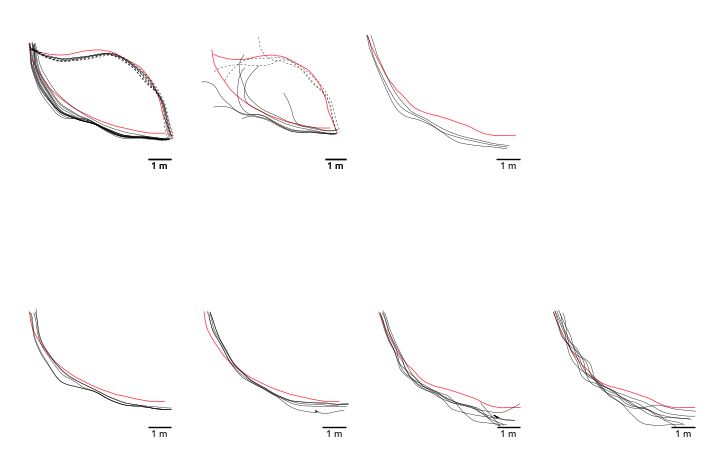

In [12]:
## Plots several indoors trajectories and save them in svg

name_fig = os.path.join(out_folder, "figure_combined_rf_in.svg")

# Convert mm to inches
width_in_inches = 180 / 25.4
height_in_inches = 150 / 25.4
line_width_points = 0.1 / 25.4 * 72
inner_line_width_points = 0.20 / 25.4 * 72

fig = plt.figure(figsize=(width_in_inches, height_in_inches))

# Define the main GridSpec layout
gs = gridspec.GridSpec(2, 4, figure=fig)

# Create subplots for different sections
ax1 = fig.add_subplot(gs[0, 0])  # First row, first column
ax2 = fig.add_subplot(gs[0, 1])  # First row, second column
ax3 = fig.add_subplot(gs[0, 2])  # First row, second column
# ax4 = fig.add_subplot(gs[0, 3])  # First row, second column

ax5 = fig.add_subplot(gs[1, 0])  # Second row, first column
ax6 = fig.add_subplot(gs[1, 1])  # Second row, second column
ax7 = fig.add_subplot(gs[1, 2])  # Second row, second column
ax8 = fig.add_subplot(gs[1, 3])  # Second row, second column

# Define nested GridSpec for ax6
# gs_nested = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=gs[2, 1], height_ratios=[2, 1])

# # Create subplots for gSpeed and Angular Velocity in the nested GridSpec
# ax6_angular = fig.add_subplot(gs_nested[0])  # Upper part for Angular Velocity
# ax6_gSpeed = fig.add_subplot(gs_nested[1])   # Lower part for gSpeed

# Plotting in ax4
for traj_nb, traj_data in df_rf_convexe_expl_a1.groupby('trajs_nb'):
    ax1.plot(traj_data['x'], traj_data['y'], linewidth=line_width_points, label=f'Trajectory {traj_nb}', linestyle=(0, (5, 5)),color='k', zorder=20)
# ax1.scatter(df_rf_convexe_learn["x"], df_rf_convexe_learn["y"], c='#ff3847ff', s=1, zorder=10)
ax1.plot(df_rf_convexe_learn["x"], df_rf_convexe_learn["y"], c='#ff3847ff',linewidth=inner_line_width_points, zorder=10)
ax1.set_aspect('equal')
ax1.set_box_aspect(1)
ax1.set_xticks([])
ax1.set_yticks([])
add_scale_bar(ax1, 1, '1 m')

for traj_nb, traj_data in df_rf_convexe_expl_a2.groupby('trajs_nb'):
    ax2.plot(traj_data['x'], traj_data['y'], linewidth=line_width_points, label=f'Trajectory {traj_nb}', linestyle=(0, (5, 5)),color='k', zorder=20)
ax2.plot(df_rf_convexe_learn["x"], df_rf_convexe_learn["y"], c='#ff3847ff',linewidth=inner_line_width_points, zorder=10)
ax2.set_aspect('equal')
ax2.set_box_aspect(1)
ax2.set_xticks([])
ax2.set_yticks([])
add_scale_bar(ax2, 1, '1 m')

# Plotting in ax1
for traj_nb, traj_data in df_rf_lightvar_expl_b1.groupby('trajs_nb'):
    ax1.plot(traj_data['x'], traj_data['y'], linewidth=line_width_points, label=f'Trajectory {traj_nb}', color='k', zorder=20)
ax1.plot(df_rf_lightvar_learn["x"], df_rf_lightvar_learn["y"], c='#ff3847ff', linewidth=inner_line_width_points, zorder=10)
ax1.set_aspect('equal')
ax1.set_box_aspect(1)
ax1.set_xticks([])
ax1.set_yticks([])
add_scale_bar(ax1, 1, '1 m')


# Plotting in ax2
for traj_nb, traj_data in df_rf_lightvar_expl_b2.groupby('trajs_nb'):
    ax2.plot(traj_data['x'], traj_data['y'], linewidth=line_width_points, label=f'Trajectory {traj_nb}', color='k', zorder=20)
ax2.plot(df_rf_lightvar_learn["x"], df_rf_lightvar_learn["y"], c='#ff3847ff', linewidth=inner_line_width_points, zorder=10)
ax2.set_aspect('equal')
ax2.set_box_aspect(1)
ax2.set_xticks([])
ax2.set_yticks([])
add_scale_bar(ax2, 1, '1 m')


# Plotting in ax1
for traj_nb, traj_data in df_rf_lightvar_expl_b3.groupby('trajs_nb'):
    ax5.plot(traj_data['x'], traj_data['y'], linewidth=line_width_points, label=f'Trajectory {traj_nb}', color='k', zorder=20)
ax5.plot(df_rf_lightvar_learn["x"], df_rf_lightvar_learn["y"], c='#ff3847ff', linewidth=inner_line_width_points, zorder=10)
ax5.set_aspect('equal')
ax5.set_box_aspect(1)
ax5.set_xticks([])
ax5.set_yticks([])
add_scale_bar(ax5, 1, '1 m')

# Plotting in ax1
for traj_nb, traj_data in df_rf_lightvar_expl_b4.groupby('trajs_nb'):
    ax6.plot(traj_data['x'], traj_data['y'], linewidth=line_width_points, label=f'Trajectory {traj_nb}', color='k', zorder=20)
ax6.plot(df_rf_lightvar_learn["x"], df_rf_lightvar_learn["y"], c='#ff3847ff', linewidth=inner_line_width_points, zorder=10)
ax6.set_aspect('equal')
ax6.set_box_aspect(1)
ax6.set_xticks([])
ax6.set_yticks([])
add_scale_bar(ax6, 1, '1 m')

for traj_nb, traj_data in df_rf_pedest_expl_c2.groupby('trajs_nb'):
    ax7.plot(traj_data['x'], traj_data['y'], linewidth=line_width_points, label=f'Trajectory {traj_nb}', color='k', zorder=20)
ax7.plot(df_rf_pedest_learn["x"], df_rf_pedest_learn["y"], c='#ff3847ff', linewidth=inner_line_width_points, zorder=10)
ax7.set_aspect('equal')
ax7.set_box_aspect(1)
ax7.set_xticks([])
ax7.set_yticks([])
add_scale_bar(ax7, 1, '1 m')

for traj_nb, traj_data in df_rf_pedest_expl_c3.groupby('trajs_nb'):
    ax8.plot(traj_data['x'], traj_data['y'], linewidth=line_width_points, label=f'Trajectory {traj_nb}', color='k', zorder=20)
ax8.plot(df_rf_pedest_learn["x"], df_rf_pedest_learn["y"], c='#ff3847ff', linewidth=inner_line_width_points, zorder=10)
ax8.set_aspect('equal')
ax8.set_box_aspect(1)
ax8.set_xticks([])
ax8.set_yticks([])
add_scale_bar(ax8, 1, '1 m')


for traj_nb, traj_data in df_rf_pedest_expl_c1.groupby('trajs_nb'):
    ax3.plot(traj_data['x'], traj_data['y'], linewidth=line_width_points, label=f'Trajectory {traj_nb}', color='k', zorder=20)
ax3.plot(df_rf_pedest_learn["x"], df_rf_pedest_learn["y"], c='#ff3847ff', linewidth=inner_line_width_points, zorder=10)
ax3.set_aspect('equal')
ax3.set_box_aspect(1)
ax3.set_xticks([])
ax3.set_yticks([])
add_scale_bar(ax3, 1, '1 m')


for ax in [ax1,ax2,ax5,ax6,ax7,ax8]:
    ax.set_ylim(-3.5,3.5)
    ax.set_xlim(-4,4)

# # Plot gSpeed in the lower subplot of ax6
# for traj_nb, traj_data in df_rf_pedest_expl_c1.groupby('trajs_nb'):
#     ax6_gSpeed.plot(traj_data["timestamp"], traj_data["gSpeed"], label='gSpeed', color='k')
# for traj_nb, traj_data in df_rf_pedest_expl_c3.groupby('trajs_nb'):
#     ax6_gSpeed.plot(traj_data["timestamp"], traj_data["gSpeed"], label='gSpeed', color='g')
# ax6_gSpeed.set_ylabel('gSpeed')

# # Plot Angular Velocity in the upper subplot of ax6
# for traj_nb, traj_data in df_rf_pedest_expl_c1.groupby('trajs_nb'):
#     ax6_angular.plot(traj_data["timestamp"], traj_data["vel_ang"], label='Angular Velocity', color='k')
# for traj_nb, traj_data in df_rf_pedest_expl_c3.groupby('trajs_nb'):
#     ax6_angular.plot(traj_data["timestamp"], traj_data["vel_ang"], label='Angular Velocity', color='g')
# # ax6_angular.plot(mean_vel_ang_c1["timestamp"], mean_vel_ang_c1["vel_ang_smoothed"], label='Angular Velocity', color='k')
# # ax6_angular.plot(mean_vel_ang_c3["timestamp"], mean_vel_ang_c3["vel_ang_smoothed"], label='Angular Velocity', color='g')
# ax6_angular.set_xlabel('Time')
# ax6_angular.set_ylabel('Angular Velocity')

# Adjust layout to avoid overlap
plt.tight_layout()
plt.show()

fig.savefig(name_fig, format='svg')


Route2, deg: 52.1010477359476
Route2, m: 0.764687535096131
Route2, deg: 0.258140648584657
Route2, m: 1.18588047551051
Route2, deg: 1.352632307042
Route2, m: 1.49800928698116
Route2, deg: 52.4567665628559
Route2, m: 0.960437527380534
Route2, deg: 53.1977759966178
Route2, m: 1.18526421871176
Route2, deg: 0.837606835375937
Route2, m: 1.8036767356155
Route2, deg: 23.7829438896959
Route2, m: 1.27298853408731
Route1, deg: 51.0573966625062
Route1, m: 1.08849156809664
Route1, deg: 51.2302767338057
Route1, m: 0.769751705682034
Route1, deg: 57.05832898595
Route1, m: 0.918436227583282


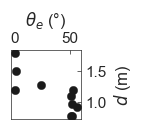

In [13]:
name_fig = os.path.join(out_folder, "kidnapped_metrics.svg")

plt.rcParams.update({
    'font.size': 7,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'axes.labelsize': 8,  # Set font size for x and y labels
    'axes.titlesize': 8,  # Set font size for titles
    'font.family': 'sans-serif',  # Ensure the global setting uses the desired font family
    'font.sans-serif': prop.get_name()  # Apply the specific font from the FontProperties object
})

# Convert mm to inches
width_in_inches = 40 / 25.4
height_in_inches = 40 / 25.4
line_width_points = 0.1 / 25.4 * 72
inner_line_width_points = 0.20 / 25.4 * 72

sns.set_theme(style="ticks")

fig = plt.figure(figsize=(width_in_inches, height_in_inches))
gs = gridspec.GridSpec(1, 1, figure=fig)
ax1 = fig.add_subplot(gs[0, 0])

for traj_nb, traj_data in df_rf_lightvar_expl_b2.groupby('trajs_nb'):
    print("Route2, deg:", traj_data['HE'].iloc[0])
    print("Route2, m:", traj_data['XTE'].iloc[0])
    ax1.scatter(traj_data['HE'].iloc[0], traj_data['XTE'].iloc[0],
                linewidth=line_width_points, label=f'Trajectory {traj_nb}', color='k', zorder=20)
    
for traj_nb, traj_data in df_rf_convexe_expl_a2.groupby('trajs_nb'):
    print("Route1, deg:", traj_data['HE'].iloc[0])
    print("Route1, m:", traj_data['XTE'].iloc[0])

    ax1.scatter(traj_data['HE'].iloc[0], traj_data['XTE'].iloc[0],
                linewidth=line_width_points, label=f'Trajectory {traj_nb}', color='k', zorder=20)

plt.xlabel(r"$\theta_e$ (°)")
plt.ylabel(r"$d$ (m)")

# Adjust tick parameters: smaller ticks, drawn inside
ax1.tick_params(axis='both', which='both', direction='in', length=3, width=0.5)

# Move x-axis to top and y-axis to right, including label positions
ax1.xaxis.tick_top()
ax1.yaxis.tick_right()
ax1.xaxis.set_label_position('top')
ax1.yaxis.set_label_position('right')

# Optionally, adjust spine thickness (box size)
for spine in ax1.spines.values():
    spine.set_linewidth(0.5)

ax1.set_box_aspect(1)
plt.tight_layout()
plt.show()

fig.savefig(name_fig, format='svg')


In [14]:
## Create a new df that group some experiemnts to compute the meadn deivation error 
df_group_for_mean = df_grouped.copy()

df_group_for_mean = df_group_for_mean[(df_group_for_mean["headingAcc"]<20) | (df_group_for_mean["headingAcc"].isna())] ## Filter the datas only when the heading accuracy is less than 50 degres (for outdoor) 

df_group_for_mean["exp_nb"] = np.where(df_group_for_mean['exp_nb'] == 'b1', 'A1', df_group_for_mean['exp_nb'])
df_group_for_mean["exp_nb"] = np.where(df_group_for_mean['exp_nb'] == 'b2', 'A2', df_group_for_mean['exp_nb'])
df_group_for_mean["exp_nb"] = np.where(df_group_for_mean['exp_nb'] == 'a1', 'A1', df_group_for_mean['exp_nb'])
df_group_for_mean["exp_nb"] = np.where(df_group_for_mean['exp_nb'] == 'a2', 'A2', df_group_for_mean['exp_nb'])
df_group_for_mean["exp_nb"] = np.where(df_group_for_mean['exp_nb'] == 'c1', 'A1', df_group_for_mean['exp_nb'])
df_group_for_mean["exp_nb"] = np.where(df_group_for_mean['exp_nb'] == 'ex_rf', 'A1', df_group_for_mean['exp_nb'])

print_counts(df_group_for_mean,'exp_nb')
print_mean_std(df_group_for_mean, 'exp_nb', ['XTE', 'HE', 'max', 'dif', 'vel_ang', 'gSpeed'])
# print_median_iqr(df_group_for_mean, 'exp_nb', ['XTE', 'HE', 'max', 'dif', 'vel_ang', 'gSpeed'])


exp_nb = A1, unique trajs_nb count = 13, with dataset of size : 7165
exp_nb = A2, unique trajs_nb count = 9, with dataset of size : 1774
exp_nb = b3, unique trajs_nb count = 5, with dataset of size : 1219
exp_nb = b4, unique trajs_nb count = 5, with dataset of size : 1211
exp_nb = c2, unique trajs_nb count = 6, with dataset of size : 1510
exp_nb = c3, unique trajs_nb count = 7, with dataset of size : 2015
exp_nb = d1, unique trajs_nb count = 2, with dataset of size : 1587
exp_nb = d2, unique trajs_nb count = 2, with dataset of size : 901
exp_nb = e1, unique trajs_nb count = 5, with dataset of size : 2375
exp_nb = f1, unique trajs_nb count = 1, with dataset of size : 1444
exp_nb = f2, unique trajs_nb count = 1, with dataset of size : 1754
exp_nb = out_L_v2, unique trajs_nb count = 9, with dataset of size : 3153
exp_nb = out_L_v2_noise, unique trajs_nb count = 5, with dataset of size : 2091
                             XTE                  HE              max  \
exp_nb                   

In [15]:
# Define the "In" and "Out" groups based on the specified experiments
in_group = ['1', '2', 'b3', 'b4', 'c2', 'c3', 'f1', 'f2']
out_group = ['d1', 'd2', 'e1','out_L_v2','out_L_v2_noise']

# Create a new column "Group" with values "In" or "Out" based on the "exp_nb"
df_group_for_mean['Group'] = df_group_for_mean['exp_nb'].apply(lambda x: 'In' if x in in_group  else 'Out')
print_counts(df_group_for_mean,'Group')
print_mean_std(df_group_for_mean, 'Group', ['XTE', 'HE', 'max', 'dif', 'vel_ang', 'gSpeed'])
print_median_iqr(df_group_for_mean, 'Group', ['XTE', 'HE', 'max', 'dif', 'vel_ang', 'gSpeed'])


exp_nb = In, unique trajs_nb count = 24, with dataset of size : 9153
exp_nb = Out, unique trajs_nb count = 21, with dataset of size : 19046
                   XTE                HE              max               dif  \
Group                                                                         
In     0.2386 ± 0.1709   5.0199 ± 5.7579  0.1363 ± 0.1241  -0.0287 ± 0.0739   
Out    0.3368 ± 0.5348  1.9422 ± 26.7854  0.1022 ± 0.0738  -0.0183 ± 0.0693   

                vel_ang           gSpeed  
Group                                     
In     1.6384 ± 10.2776  0.5803 ± 0.2798  
Out     0.1553 ± 7.8743    0.7471 ± 0.29  

XTE Statistics by Group:
         Median       IQR
Group                    
In     0.192078  0.203918
Out    0.258104  0.359169

HE Statistics by Group:
         Median       IQR
Group                    
In     3.175830  5.301632
Out    2.050436  7.551427

max Statistics by Group:
         Median   IQR
Group                
In     0.100000  0.12
Out    0.085714  0.0

In [16]:
df_group_for_mean

,timestamp,x,y,heading,gSpeed,vel_ang,unfa0,unfa1,unfa2,unfa3,...,cumulative_distance,exp_nb,latitude,longitude,speedAcc,headingAcc,s,d_place,weights,Group
11001,8.031675,2.295582,7.504530e-01,-32.317444,0.714961,-5.043468,0.030000,0.010000,NaN,NaN,...,5.215479,A1,NaN,NaN,NaN,NaN,NaN,NaN,0.000031,Out
11791,10.950926,3.144669,-8.031943e-01,-43.467813,0.635518,-2.736424,0.020000,0.030000,NaN,NaN,...,6.992772,A1,NaN,NaN,NaN,NaN,NaN,NaN,0.000031,Out
11790,10.831865,3.123978,-7.260174e-01,-42.897613,0.703756,-4.360873,0.020000,0.020000,NaN,NaN,...,6.912869,A1,NaN,NaN,NaN,NaN,NaN,NaN,0.000031,Out
11789,10.719416,3.104290,-6.546862e-01,-42.375214,0.756813,-5.796537,0.040000,0.010000,NaN,NaN,...,6.838871,A1,NaN,NaN,NaN,NaN,NaN,NaN,0.000031,Out
11788,10.625333,3.086070,-5.952573e-01,-41.787290,0.778654,-6.569051,0.050000,0.010000,NaN,NaN,...,6.776712,A1,NaN,NaN,NaN,NaN,NaN,NaN,0.000031,Out
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28292,23.493480,698442.120096,4.789355e+06,-158.108095,0.850853,2.022882,0.100000,0.033333,NaN,NaN,...,15.101879,out_L_v2_noise,43.230893,5.443747,107.458839,6.634671,NaN,NaN,0.000037,Out
28291,23.435725,698442.133329,4.789355e+06,-159.096316,0.848972,2.029052,0.140000,0.060000,NaN,NaN,...,15.054059,out_L_v2_noise,43.230893,5.443747,108.211062,6.644023,NaN,NaN,0.000037,Out
28290,23.351962,698442.152522,4.789355e+06,-160.529558,0.846245,2.038000,0.173333,0.053333,NaN,NaN,...,14.984705,out_L_v2_noise,43.230894,5.443747,109.302030,6.657586,NaN,NaN,0.000037,Out
28304,24.426930,698441.936733,4.789355e+06,-146.514507,0.862184,1.906614,0.093333,0.253333,NaN,NaN,...,15.674183,out_L_v2_noise,43.230888,5.443744,100.189790,6.425534,NaN,NaN,0.000037,Out


## Outdoor Route following experiments

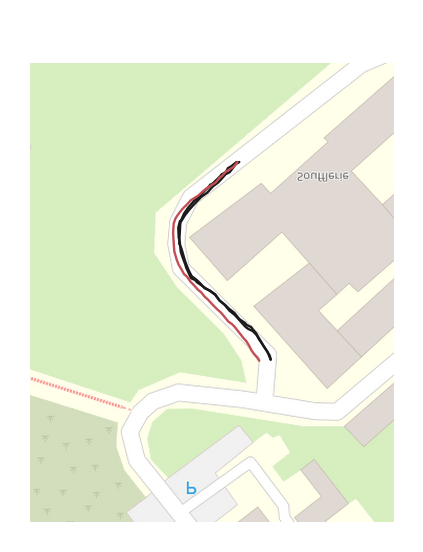

In [17]:
## Plot the Outdoor route following for Day 2 in a basemap
# Convert mm to inches for figure size and line widths
width_in_inches = 180 / 25.4
height_in_inches = 130 / 25.4
line_width_points = 0.2 / 25.4 * 72
inner_line_width_points = 0.20 / 25.4 * 72

# Initialize tilemapbase
tilemapbase.init(create=True)

# Define the extent of the map based on your data, with a small expansion to ensure visibility
expand = 0.00009
extent = tilemapbase.Extent.from_lonlat(
    df_home_out_expl_h1.longitude.min() - expand,
    df_home_out_expl_h1.longitude.max() + expand,
    df_home_out_expl_h1.latitude.min() - expand,
    df_home_out_expl_h1.latitude.max() + expand,
)

# Set up map tiles
tiles = tilemapbase.tiles.build_OSM()

# Create the figure and axis
fig, ax = plt.subplots(figsize=(2, 2), dpi=300)
ax.xaxis.set_visible(False)
ax.yaxis.set_visible(False)

# Plot the map tiles with a larger height to display more surrounding map area
plotter = tilemapbase.Plotter(extent, tiles, height=1200)  # Increased height to show more map tiles
plotter.plot(ax, tiles, alpha=0.8)

# Adjust xlim and ylim to display more map around the trajectory without changing extent
padding = 0.0000007  # Adjust this padding value to show more of the surrounding map
ax.set_xlim([extent.xmin - padding, extent.xmax + padding])
ax.set_ylim([extent.ymin - padding, extent.ymax + padding])

# Plot each trajectory separately
for traj_nb, traj_data in df_rf_out_expl_o2.groupby('trajs_nb'):
    # Project each group's data
    traj_projected = traj_data.apply(
        lambda x: tilemapbase.project(x.longitude, x.latitude), axis=1
    ).apply(pd.Series)
    traj_projected.columns = ["x", "y"]
    
    # Plot the trajectory
    ax.plot(traj_projected.x, traj_projected.y, linewidth=line_width_points, color='k')

# Plot the second trajectory in red
traj_projected = df_rf_out_learn.apply(lambda x: tilemapbase.project(x.longitude, x.latitude), axis=1).apply(pd.Series)
traj_projected.columns = ["x", "y"]
ax.plot(traj_projected.x, traj_projected.y, linewidth=line_width_points, color='r')

# Optional: plot another dataset if needed
# Example: ax.plot(df_rf_out_learn["x"], df_rf_out_learn["y"], c='#ff3847ff', linewidth=inner_line_width_points, zorder=10)

# Remove axis for cleaner look
plt.axis('off')
plt.tight_layout()

# Show the plot
plt.show()

# Save the figure
fig.savefig(os.path.join(out_folder, "fIGURE_rf_day2.svg"), format='svg')


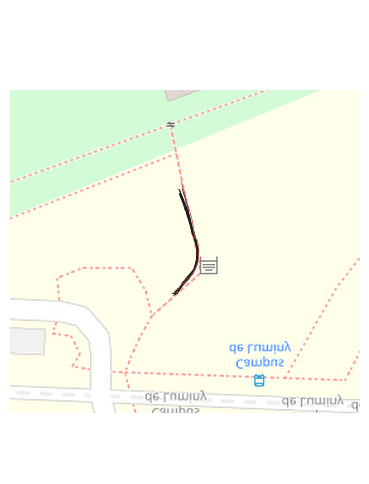

In [18]:
## Plot the Outdoor route following for Day 2 in a basemap
# Convert mm to inches for figure size and line widths
width_in_inches = 180 / 25.4
height_in_inches = 130 / 25.4
line_width_points = 0.2 / 25.4 * 72
inner_line_width_points = 0.20 / 25.4 * 72

# Initialize tilemapbase
tilemapbase.init(create=True)

# Define the extent of the map based on your data, with a small expansion to ensure visibility
expand = 0.00009
extent = tilemapbase.Extent.from_lonlat(
    df_lv2_exploit.longitude.min() - expand,
    df_lv2_exploit.longitude.max() + expand,
    df_lv2_exploit.latitude.min() - expand,
    df_lv2_exploit.latitude.max() + expand,
)

# Set up map tiles
tiles = tilemapbase.tiles.build_OSM()

# Create the figure and axis
fig, ax = plt.subplots(figsize=(5, 5))
ax.xaxis.set_visible(False)
ax.yaxis.set_visible(False)

# Plot the map tiles with a larger height to display more surrounding map area
plotter = tilemapbase.Plotter(extent, tiles, height=1200)  # Increased height to show more map tiles
plotter.plot(ax, tiles, alpha=0.8)

# Adjust xlim and ylim to display more map around the trajectory without changing extent
padding = 0.0000007  # Adjust this padding value to show more of the surrounding map
ax.set_xlim([extent.xmin - padding, extent.xmax + padding])
ax.set_ylim([extent.ymin - padding, extent.ymax + padding])
# add_scale_bar(ax, 1, '1 m')

# Plot each trajectory separately
for traj_nb, traj_data in df_lv2_exploit.groupby('trajs_nb'):
    # Project each group's data
    traj_projected = traj_data.apply(
        lambda x: tilemapbase.project(x.longitude, x.latitude), axis=1
    ).apply(pd.Series)
    traj_projected.columns = ["x", "y"]
    if traj_nb not in [8,12,13,14,15,16,17]:
        # Plot the trajectory
        if traj_data["trajs_nb"].iloc[0] == 17: ## 7spotradius(fail)
            ax.plot(traj_projected.x, traj_projected.y, linewidth=line_width_points, color='gray')
        elif traj_data["trajs_nb"].iloc[0] == 16: ##6spotradius
            ax.plot(traj_projected.x, traj_projected.y, linewidth=line_width_points, color='0.6')
        elif traj_data["trajs_nb"].iloc[0] == 15: ##5spotradius
            ax.plot(traj_projected.x, traj_projected.y, linewidth=line_width_points, color='0.7')
        elif (traj_data["trajs_nb"].iloc[0] == 12) | (traj_data["trajs_nb"].iloc[0] == 13) | (traj_data["trajs_nb"].iloc[0] == 14): ##3spotradius
            ax.plot(traj_projected.x, traj_projected.y, linewidth=line_width_points, color='0.8')
        else: 
            ax.plot(traj_projected.x, traj_projected.y, linewidth=line_width_points, color='k')

# Plot the second trajectory in red
traj_projected = df_lv2_learn.apply(lambda x: tilemapbase.project(x.longitude, x.latitude), axis=1).apply(pd.Series)
traj_projected.columns = ["x", "y"]
ax.plot(traj_projected.x, traj_projected.y, linewidth=line_width_points, color='r')

# Optional: plot another dataset if needed
# Example: ax.plot(df_rf_out_learn["x"], df_rf_out_learn["y"], c='#ff3847ff', linewidth=inner_line_width_points, zorder=10)

# Remove axis for cleaner look
plt.axis('off')
plt.tight_layout()

# Show the plot
plt.show()

# Save the figure
fig.savefig(os.path.join(out_folder, "fig_out_LV2.svg"), format='svg')


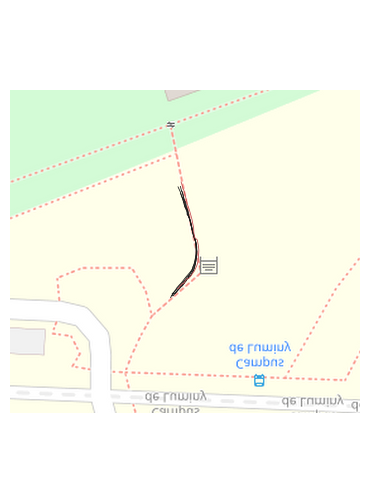

In [19]:
## Plot the Outdoor route following for Day 2 in a basemap
# Convert mm to inches for figure size and line widths
width_in_inches = 180 / 25.4
height_in_inches = 130 / 25.4
line_width_points = 0.2 / 25.4 * 72
inner_line_width_points = 0.20 / 25.4 * 72

# Initialize tilemapbase
tilemapbase.init(create=True)

# Define the extent of the map based on your data, with a small expansion to ensure visibility
expand = 0.00009
extent = tilemapbase.Extent.from_lonlat(
    df_lv2_exploit.longitude.min() - expand,
    df_lv2_exploit.longitude.max() + expand,
    df_lv2_exploit.latitude.min() - expand,
    df_lv2_exploit.latitude.max() + expand,
)

# Set up map tiles
tiles = tilemapbase.tiles.build_OSM()

# Create the figure and axis
fig, ax = plt.subplots(figsize=(5, 5))
ax.xaxis.set_visible(False)
ax.yaxis.set_visible(False)

# Plot the map tiles with a larger height to display more surrounding map area
plotter = tilemapbase.Plotter(extent, tiles, height=1200)  # Increased height to show more map tiles
plotter.plot(ax, tiles, alpha=0.8)

# Adjust xlim and ylim to display more map around the trajectory without changing extent
padding = 0.0000007  # Adjust this padding value to show more of the surrounding map
ax.set_xlim([extent.xmin - padding, extent.xmax + padding])
ax.set_ylim([extent.ymin - padding, extent.ymax + padding])
# add_scale_bar(ax, 1, '1 m')

# Plot each trajectory separately
for traj_nb, traj_data in df_lv2_exploit.groupby('trajs_nb'):
    # Project each group's data
    traj_projected = traj_data.apply(
        lambda x: tilemapbase.project(x.longitude, x.latitude), axis=1
    ).apply(pd.Series)
    traj_projected.columns = ["x", "y"]
    if traj_nb in [12,13,14,15,16]:
        # Plot the trajectory
            ax.plot(traj_projected.x, traj_projected.y, linewidth=line_width_points, color='k')

# Plot the second trajectory in red
traj_projected = df_lv2_learn.apply(lambda x: tilemapbase.project(x.longitude, x.latitude), axis=1).apply(pd.Series)
traj_projected.columns = ["x", "y"]
ax.plot(traj_projected.x, traj_projected.y, linewidth=line_width_points, color='r')

# Optional: plot another dataset if needed
# Example: ax.plot(df_rf_out_learn["x"], df_rf_out_learn["y"], c='#ff3847ff', linewidth=inner_line_width_points, zorder=10)

# Remove axis for cleaner look
plt.axis('off')
plt.tight_layout()

# Show the plot
plt.show()

# Save the figure
fig.savefig(os.path.join(out_folder, "fig_out_LV2_2.svg"), format='svg')


In [20]:
import simplekml

# Function to map trajectory numbers to KML hex colors (aabbggrr format)
def get_color(traj_nb):
    if traj_nb == 17:          # 7spotradius (fail)
        return "ff808080"  # Gray
    elif traj_nb == 16:        # 6spotradius
        return "ff999999"  # Medium-light gray
    elif traj_nb == 15:        # 5spotradius
        return "ffb3b3b3"  # Lighter gray
    elif traj_nb in [12, 13, 14]:  # 3spotradius
        return "ffcccccc"  # Even lighter gray
    else:
        return "ff000000"  # Black

# Create a new KML object
kml = simplekml.Kml()

# Create KML LineStrings for each trajectory in the exploitation DataFrame
for traj_nb, traj_data in df_lv2_exploit.groupby('trajs_nb'):
    if traj_nb not in [8,12,13,14,15,16,17]:
        # Create a list of (longitude, latitude) tuples
        coords = list(zip(traj_data.longitude, traj_data.latitude))

        # Create a new LineString for this trajectory
        ls = kml.newlinestring(name=f"Trajectory {traj_nb}")
        ls.coords = coords
        ls.style.linestyle.color = get_color(traj_nb)
        ls.style.linestyle.width = 3

# Create a KML LineString for the learning trajectory (in red)
coords_learn = list(zip(df_lv2_learn.longitude, df_lv2_learn.latitude))
ls_learn = kml.newlinestring(name="Learning Trajectory")
ls_learn.coords = coords_learn
ls_learn.style.linestyle.color = simplekml.Color.red
ls_learn.style.linestyle.width = 3

# Save the KML file (adjust the file path if needed)
kml.save("trajectories.kml")


In [21]:

# Function to map trajectory numbers to KML hex colors (aabbggrr format)
def get_color(traj_nb):
    if traj_nb == 17:          # 7spotradius (fail)
        return "ff000000"  # Gray
    elif traj_nb == 16:        # 6spotradius
        return "ff000000"  # Medium-light gray
    elif traj_nb == 15:        # 5spotradius
        return "ff000000"  # Lighter gray
    elif traj_nb in [12, 13, 14]:  # 3spotradius
        return "ff000000"  # Even lighter gray
    else:
        return "ff000000"  # Black

# Create a new KML object
kml = simplekml.Kml()

# Create KML LineStrings for each trajectory in the exploitation DataFrame
for traj_nb, traj_data in df_lv2_exploit.groupby('trajs_nb'):
    if traj_nb in [12,13,14,15,16]:
        # Create a list of (longitude, latitude) tuples
        coords = list(zip(traj_data.longitude, traj_data.latitude))

        # Create a new LineString for this trajectory
        ls = kml.newlinestring(name=f"Trajectory {traj_nb}")
        ls.coords = coords
        ls.style.linestyle.color = get_color(traj_nb)
        ls.style.linestyle.width = 3

# Create a KML LineString for the learning trajectory (in red)
coords_learn = list(zip(df_lv2_learn.longitude, df_lv2_learn.latitude))
ls_learn = kml.newlinestring(name="Learning Trajectory")
ls_learn.coords = coords_learn
ls_learn.style.linestyle.color = simplekml.Color.red
ls_learn.style.linestyle.width = 3

# Save the KML file (adjust the file path if needed)
kml.save("trajectories_noise.kml")

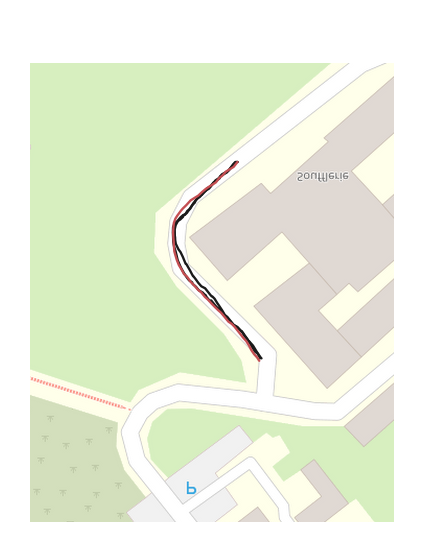

In [22]:
## Plot the Outdoor route following for Day 1 in a basemap

# Convert mm to inches for figure size and line widths
width_in_inches = 180 / 25.4
height_in_inches = 130 / 25.4
line_width_points = 0.2 / 25.4 * 72
inner_line_width_points = 0.20 / 25.4 * 72

# Initialize tilemapbase
tilemapbase.init(create=True)

# Define the extent of the map based on your data, with a small expansion to ensure visibility
expand = 0.00009
extent = tilemapbase.Extent.from_lonlat(
    df_home_out_expl_h1.longitude.min() - expand,
    df_home_out_expl_h1.longitude.max() + expand,
    df_home_out_expl_h1.latitude.min() - expand,
    df_home_out_expl_h1.latitude.max() + expand,
)

# Set up map tiles
tiles = tilemapbase.tiles.build_OSM()

# Create the figure and axis
fig, ax = plt.subplots(figsize=(2, 2), dpi=300)
ax.xaxis.set_visible(False)
ax.yaxis.set_visible(False)

# Plot the map tiles with a larger height to display more surrounding map area
plotter = tilemapbase.Plotter(extent, tiles, height=1200)  # Increased height to show more map tiles
plotter.plot(ax, tiles, alpha=0.8)

# Adjust xlim and ylim to display more map around the trajectory without changing extent
padding = 0.0000007  # Adjust this padding value to show more of the surrounding map
ax.set_xlim([extent.xmin - padding, extent.xmax + padding])
ax.set_ylim([extent.ymin - padding, extent.ymax + padding])

# Plot each trajectory separately
for traj_nb, traj_data in df_rf_out_expl_o1.groupby('trajs_nb'):
    # Project each group's data
    traj_projected = traj_data.apply(
        lambda x: tilemapbase.project(x.longitude, x.latitude), axis=1
    ).apply(pd.Series)
    traj_projected.columns = ["x", "y"]
    
    # Plot the trajectory
    ax.plot(traj_projected.x, traj_projected.y, linewidth=line_width_points, color='k')

# Plot the second trajectory in red
traj_projected = df_rf_out_learn.apply(lambda x: tilemapbase.project(x.longitude, x.latitude), axis=1).apply(pd.Series)
traj_projected.columns = ["x", "y"]
ax.plot(traj_projected.x, traj_projected.y, linewidth=line_width_points, color='r')

# Optional: plot another dataset if needed
# Example: ax.plot(df_rf_out_learn["x"], df_rf_out_learn["y"], c='#ff3847ff', linewidth=inner_line_width_points, zorder=10)

# Remove axis for cleaner look
plt.axis('off')
plt.tight_layout()

# Show the plot
plt.show()

# Save the figure
fig.savefig(os.path.join(out_folder, "fIGURE_rf_day1.svg"), format='svg')


kml = simplekml.Kml()

# Create KML LineStrings for each trajectory in the exploitation DataFrame
for traj_nb, traj_data in df_rf_out_expl_o1.groupby('trajs_nb'):
    # Create a list of (longitude, latitude) tuples
    coords = list(zip(traj_data.longitude, traj_data.latitude))

    # Create a new LineString for this trajectory
    ls = kml.newlinestring(name=f"Trajectory {traj_nb}")
    ls.coords = coords
    ls.style.linestyle.color = "ff000000"
    ls.style.linestyle.width = 3

# Create a KML LineString for the learning trajectory (in red)
coords_learn = list(zip(df_rf_out_learn.longitude, df_rf_out_learn.latitude))
ls_learn = kml.newlinestring(name="Learning Trajectory")
ls_learn.coords = coords_learn
ls_learn.style.linestyle.color = simplekml.Color.red
ls_learn.style.linestyle.width = 3

# Save the KML file (adjust the file path if needed)
kml.save("trajectories_day1_out.kml")



In [23]:
df_rf_out_learn

,timestamp,x,y,heading,gSpeed,vel_ang,unfa0,unfa1,unfa2,unfa3,...,inn_trajs_nb,max,total_length,cumulative_distance,exp_nb,latitude,longitude,speedAcc,headingAcc,s
17262,5.778716,698421.055786,4.789687e+06,-57.617956,0.516385,8.653919,0.006711,0.000000,NaN,NaN,...,NaN,0.006711,54.034017,0.197101,o1,43.233883,5.443607,75.272039,10.557123,NaN
17263,6.864972,698420.249953,4.789688e+06,-44.214857,0.874241,8.398113,0.100671,0.322148,NaN,NaN,...,NaN,0.322148,54.034017,1.464119,o1,43.233892,5.443597,76.277138,6.088005,NaN
17264,8.045826,698419.440352,4.789688e+06,-52.689088,0.846248,8.198899,0.228188,0.718121,NaN,NaN,...,NaN,0.718121,54.034017,2.402805,o1,43.233896,5.443587,77.150418,6.450512,NaN
17265,9.303844,698418.560919,4.789689e+06,-53.417444,0.843219,7.960401,0.241611,0.275168,NaN,NaN,...,NaN,0.275168,54.034017,3.414427,o1,43.233901,5.443577,77.445266,6.774707,NaN
17266,10.372460,698417.830142,4.789690e+06,-49.355319,0.868484,7.696489,0.154362,0.395973,NaN,NaN,...,NaN,0.395973,54.034017,4.486410,o1,43.233908,5.443568,75.322594,6.377806,NaN
17267,11.491822,698417.120428,4.789690e+06,-46.258966,0.879641,7.395219,0.134228,0.362416,NaN,NaN,...,NaN,0.362416,54.034017,5.365257,o1,43.233913,5.443560,79.743883,6.360623,NaN
17268,12.605078,698416.435034,4.789691e+06,-45.774651,0.885042,7.108185,0.087248,0.355705,NaN,NaN,...,NaN,0.355705,54.034017,6.456950,o1,43.233921,5.443551,76.112679,6.026840,NaN
17269,13.602162,698415.742472,4.789691e+06,-55.215033,0.846729,6.465012,0.221477,0.147651,NaN,NaN,...,NaN,0.221477,54.034017,7.268005,o1,43.233925,5.443543,77.086426,6.580274,NaN
17270,14.648890,698415.004073,4.789692e+06,-51.815187,0.878482,5.905194,0.228188,0.080537,NaN,NaN,...,NaN,0.228188,54.034017,8.119563,o1,43.233929,5.443534,79.094469,6.119705,NaN
17271,15.838053,698414.249997,4.789692e+06,-50.561805,0.826033,3.538037,0.127517,0.127517,NaN,NaN,...,NaN,0.127517,54.034017,9.011790,o1,43.233934,5.443525,80.271173,6.580103,NaN


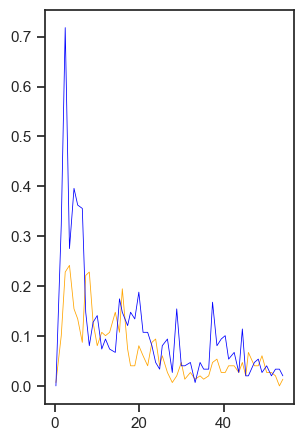

In [24]:
fig = plt.figure(figsize=(width_in_inches, height_in_inches))

gs = GridSpec(1, 2, figure=fig)
# identical to ax1 = plt.subplot(gs.new_subplotspec((0, 0), colspan=3))

ax1 = fig.add_subplot(gs[0])

ax1.plot(df_rf_out_learn["cumulative_distance"],df_rf_out_learn["unfa0"], c='orange',linewidth=inner_line_width_points,zorder=10)
ax1.plot(df_rf_out_learn["cumulative_distance"],df_rf_out_learn["unfa1"], c='blue',linewidth=inner_line_width_points,zorder=10)


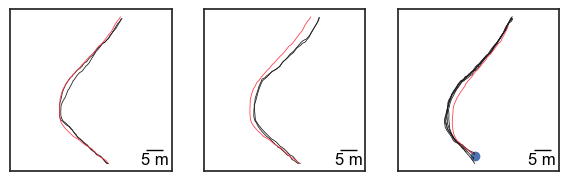

In [25]:
## Plot the outdoor trajectories in the cartesian space
# Convert mm to inches
width_in_inches = 180 / 25.4
height_in_inches = 130 / 25.4
line_width_points = 0.2 / 25.4 * 72
inner_line_width_points = 0.20 / 25.4 * 72

fig = plt.figure(figsize=(width_in_inches, height_in_inches))

gs = GridSpec(1, 3, figure=fig)
# identical to ax1 = plt.subplot(gs.new_subplotspec((0, 0), colspan=3))

ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])
ax3 = fig.add_subplot(gs[2])

# Plot the second plot
# df_rf_convexe_expl_1tra = df_rf_pedest_expl[df_rf_pedest_expl["trajs_nb"]==1]
# ax1.plot(df_rf_convexe_expl_1tra['x'], df_rf_convexe_expl_1tra['y'], linewidth=line_width_points, color='k')

for traj_nb, traj_data in df_rf_out_expl_o1.groupby('trajs_nb'):
    ax1.plot(traj_data['x'], traj_data['y'], linewidth=line_width_points, color='k')
ax1.plot(df_rf_out_learn["x"], df_rf_out_learn["y"], c='#ff3847ff',linewidth=inner_line_width_points,zorder=10)
ax1.set_aspect('equal')
ax1.set_box_aspect(1)
ax1.set_xticks([])
ax1.set_yticks([])
add_scale_bar(ax1, 5, '5 m')

for traj_nb, traj_data in df_rf_out_expl_o2.groupby('trajs_nb'):
    ax2.plot(traj_data['x'], traj_data['y'], linewidth=line_width_points, color='k')
ax2.plot(df_rf_out_learn["x"], df_rf_out_learn["y"], c='#ff3847ff',linewidth=inner_line_width_points,zorder=10)
ax2.set_aspect('equal')
ax2.set_box_aspect(1)
ax2.set_xticks([])
ax2.set_yticks([])
add_scale_bar(ax2, 5, '5 m')

for traj_nb, traj_data in df_home_out_expl_h1.groupby('trajs_nb'):
    ax3.plot(traj_data['x'], traj_data['y'], linewidth=line_width_points, color='k')
ax3.plot(df_home_out_learn["x"], df_home_out_learn["y"], c='#ff3847ff',linewidth=inner_line_width_points,zorder=10)
ax3.set_aspect('equal')
ax3.set_box_aspect(1)
ax3.set_xticks([])
ax3.set_yticks([])
add_scale_bar(ax3, 5, '5 m')

ax3.scatter(mean_x_inbound_home,mean_y_inbound_home)

fig.savefig(os.path.join(out_folder, "figure_combined_RF_HOME_OUT.svg"), format='svg')

kml = simplekml.Kml()


# Create KML LineStrings for each trajectory in the exploitation DataFrame
for traj_nb, traj_data in df_rf_out_expl_o2.groupby('trajs_nb'):
    # Create a list of (longitude, latitude) tuples
    coords = list(zip(traj_data.longitude, traj_data.latitude))

    # Create a new LineString for this trajectory
    ls = kml.newlinestring(name=f"Trajectory {traj_nb}")
    ls.coords = coords
    ls.style.linestyle.color = "ff000000"
    ls.style.linestyle.width = 3

# Create a KML LineString for the learning trajectory (in red)
coords_learn = list(zip(df_rf_out_learn.longitude, df_rf_out_learn.latitude))
ls_learn = kml.newlinestring(name="Learning Trajectory")
ls_learn.coords = coords_learn
ls_learn.style.linestyle.color = simplekml.Color.red
ls_learn.style.linestyle.width = 3

# Save the KML file (adjust the file path if needed)
kml.save("trajectories_day2_out.kml")

kml = simplekml.Kml()

# Create KML LineStrings for each trajectory in the exploitation DataFrame
for traj_nb, traj_data in df_home_out_expl_h1.groupby('trajs_nb'):
    # Create a list of (longitude, latitude) tuples
    coords = list(zip(traj_data.longitude, traj_data.latitude))

    # Create a new LineString for this trajectory
    ls = kml.newlinestring(name=f"Trajectory {traj_nb}")
    ls.coords = coords
    ls.style.linestyle.color = "ff000000"
    ls.style.linestyle.width = 3

# Create a KML LineString for the learning trajectory (in red)
coords_learn = list(zip(df_home_out_learn.longitude, df_home_out_learn.latitude))
ls_learn = kml.newlinestring(name="Learning Trajectory")
ls_learn.coords = coords_learn
ls_learn.style.linestyle.color = simplekml.Color.red
ls_learn.style.linestyle.width = 3

# Save the KML file (adjust the file path if needed)
kml.save("trajectories_home_out.kml")



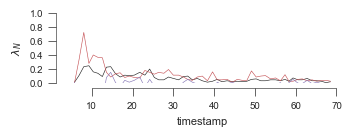

In [26]:
## Plot the Unfamiliarity value for place MBONs during Homing Experiments over distance, change style and save as svg
name_fig = os.path.join(out_folder, "fig_shuttling_familiarity_over_time.svg")

sns.set_theme(style="ticks")
plt.rcParams.update({
    'font.size': 7,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'axes.labelsize': 8,  # Set font size for x and y labels
    'axes.titlesize': 8,  # Set font size for titles
    'font.family': 'sans-serif',  # Ensure the global setting uses the desired font family
    'font.sans-serif': prop.get_name()  # Apply the specific font from the FontProperties object
})


# Convert mm to inches
width_in_inches = 90 / 25.4
height_in_inches = 35 / 25.4
line_width_points = 0.1 / 25.4 * 72
inner_line_width_points = 0.15 / 25.4 * 72
little_width_points = 0.05 / 25.4 * 72

fig, ax1 = plt.subplots(figsize=(width_in_inches, height_in_inches))
sns.lineplot(ax=ax1, data = df_rf_out_learn,x="timestamp",y="unfa0",color='k',legend=False,linewidth=inner_line_width_points)
sns.lineplot(ax=ax1, data = df_rf_out_learn,x="timestamp",y="unfa1",color='r',legend=False,linewidth=inner_line_width_points)
sns.lineplot(ax=ax1, data = df_rf_out_learn,x="timestamp",y="dif",color='m',legend=False,linewidth=inner_line_width_points)

ax1.set_ylim([0,1])
# ax1.set_xlim([0,60])
# ax1.set_yticks([0,0.5,1])
sns.despine(ax=ax1, offset=4, trim=True)
# Set the external line width for the joint plot
ax1.spines['bottom'].set_linewidth(inner_line_width_points)
ax1.spines['left'].set_linewidth(inner_line_width_points)
ax1.tick_params(axis='both', width=0.5)  # Adjust tick thickness
# ax1.set_xlabel("Distance traveled (m)")
ax1.set_ylabel(r"$\lambda_{N}$")
plt.tight_layout()

fig.savefig(name_fig, format='svg')

Number of KCs : 14884


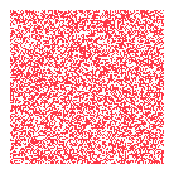

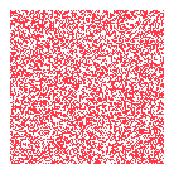

In [27]:
## Plots the shared MBONs during day 1 and 2 from the csr matrix
# fig.savefig(os.path.join(out_folder, "figure_combined_rf_in.svg"), format='svg')

csr_matrix = load_npz('/home/gat/Documents/TheAntcarShuttle_analysis/data/raw/rosbag/Route_Following/Outdoor/memory_compressed.npz')
    
# Convert CSR matrix to dense format
dense_matrix = csr_matrix.toarray()
mbonl = dense_matrix[:,0]
mbonr = dense_matrix[:,1]
print(f"Number of KCs : {len(mbonr)}")

plot_and_save_csr_matrix(mbonl,out_folder + '/mbonl.svg')
plot_and_save_csr_matrix(mbonr,out_folder + '/mbonr.svg')

In [28]:
## Investigate memory footprint
src_out_a = '../data/raw/'
memories_learning_AVM_line = pd.read_csv(src_out_a+'memories_learning.csv') 

output_file_path =  src_out_a + '/memory_compressed.npz'

img_folder = '/home/gat/Documents/TheAntcarShuttle_analysis/data/raw/rosbag/Route_Following/Outdoor/xp_ext_L_50m_ok/first_cars_online_learing/learned_image/left_img'
# Get the size of the folder
folder_size1 = get_folder_size(img_folder)
img_folder = '/home/gat/Documents/TheAntcarShuttle_analysis/data/raw/rosbag/Route_Following/Outdoor/xp_ext_L_50m_ok/first_cars_online_learing/learned_image/right_img'
# Get the size of the folder
folder_size2 = get_folder_size(img_folder)

perfect_memory_size = folder_size1 + folder_size2

memory_csr =  '/home/gat/Documents/TheAntcarShuttle_analysis/data/raw/rosbag/Route_Following/Outdoor/memory_compressed.npz'
file_size = os.path.getsize(memory_csr)

print(f"Size of the route memories in csr : {convert_bytes_to_human_readable(file_size)}")
print(f"Size of the raw image in the folder : {convert_bytes_to_human_readable(perfect_memory_size)}")
print(f"Compression rate of {100-(file_size*100)/perfect_memory_size:.2f}%")


Size of the route memories in csr : 18.53 KB
Size of the raw image in the folder : 53.27 MB
Compression rate of 99.97%


## Outdoor Homing experiments

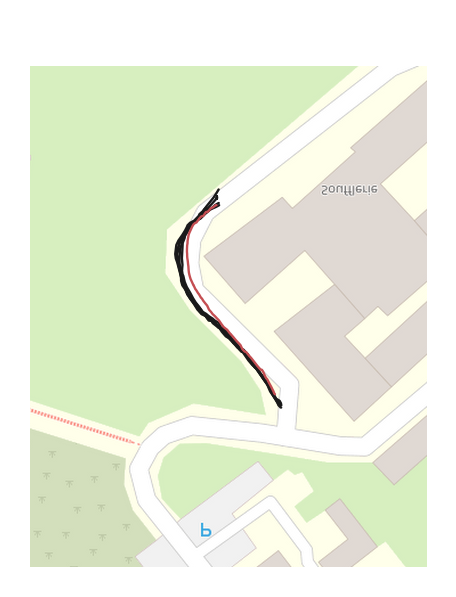

In [29]:
## Plot the Outdoor homing trajectory using GNSS datas on map plan
# Convert mm to inches for figure size and line widths
width_in_inches = 180 / 25.4
height_in_inches = 130 / 25.4
line_width_points = 0.2 / 25.4 * 72
inner_line_width_points = 0.20 / 25.4 * 72

# Initialize tilemapbase
tilemapbase.init(create=True)

# Define the extent of the map based on your data, with a small expansion to ensure visibility
expand = 0.00009
extent = tilemapbase.Extent.from_lonlat(
    df_home_out_expl_h1.longitude.min() - expand,
    df_home_out_expl_h1.longitude.max() + expand,
    df_home_out_expl_h1.latitude.min() - expand,
    df_home_out_expl_h1.latitude.max() + expand,
)

# Set up map tiles
tiles = tilemapbase.tiles.build_OSM()

# Create the figure and axis
fig, ax = plt.subplots(figsize=(2, 2), dpi=300)
ax.xaxis.set_visible(False)
ax.yaxis.set_visible(False)

# Plot the map tiles with a larger height to display more surrounding map area
plotter = tilemapbase.Plotter(extent, tiles, height=1200)  # Increased height to show more map tiles
plotter.plot(ax, tiles, alpha=0.8)

# Adjust xlim and ylim to display more map around the trajectory without changing extent
padding = 0.0000007  # Adjust this padding value to show more of the surrounding map
ax.set_xlim([extent.xmin - padding, extent.xmax + padding])
ax.set_ylim([extent.ymin - padding, extent.ymax + padding])

# Plot each trajectory separately
for traj_nb, traj_data in df_home_out_expl_h1.groupby('trajs_nb'):
    # Project each group's data
    traj_projected = traj_data.apply(
        lambda x: tilemapbase.project(x.longitude, x.latitude), axis=1
    ).apply(pd.Series)
    traj_projected.columns = ["x", "y"]
    
    # Plot the trajectory
    ax.plot(traj_projected.x, traj_projected.y, linewidth=line_width_points, color='k')

# Plot the second trajectory in red
traj_projected = df_home_out_learn.apply(lambda x: tilemapbase.project(x.longitude, x.latitude), axis=1).apply(pd.Series)
traj_projected.columns = ["x", "y"]
ax.plot(traj_projected.x, traj_projected.y, linewidth=line_width_points, color='r')

# Optional: plot another dataset if needed
# Example: ax.plot(df_rf_out_learn["x"], df_rf_out_learn["y"], c='#ff3847ff', linewidth=inner_line_width_points, zorder=10)

# Remove axis for cleaner look
plt.axis('off')
plt.tight_layout()

# Show the plot
plt.show()

# Save the figure
fig.savefig(os.path.join(out_folder, "FIGURE_HOMING_BLANKMAP.svg"), format='svg')


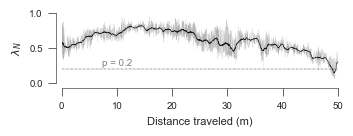

In [30]:
## Plot the Unfamiliarity value for place MBONs during Homing Experiments over distance, change style and save as svg
name_fig = os.path.join(out_folder, "fig_shuttling_trajs.svg")

sns.set_theme(style="ticks")
plt.rcParams.update({
    'font.size': 7,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'axes.labelsize': 8,  # Set font size for x and y labels
    'axes.titlesize': 8,  # Set font size for titles
    'font.family': 'sans-serif',  # Ensure the global setting uses the desired font family
    'font.sans-serif': prop.get_name()  # Apply the specific font from the FontProperties object
})

mean_unfa2 = df_home_out_expl_h1.groupby('cumulative_distance')['unfa2'].mean().reset_index()

# Apply Savitzky-Golay filter to smooth the mean values
window_length = 31  # Choose an odd number
polyorder = 1  # Polynomial order
mean_unfa2['smoothed_unfa2'] = savgol_filter(mean_unfa2['unfa2'], window_length, polyorder)

# Convert mm to inches
width_in_inches = 90 / 25.4
height_in_inches = 35 / 25.4
line_width_points = 0.1 / 25.4 * 72
inner_line_width_points = 0.15 / 25.4 * 72
little_width_points = 0.05 / 25.4 * 72

fig, ax1 = plt.subplots(figsize=(width_in_inches, height_in_inches))

sns.lineplot(ax=ax1, data = df_home_out_expl_h1,x="cumulative_distance",y="unfa2",color='0.7',legend=False,linewidth=little_width_points)
sns.lineplot(ax=ax1, data = mean_unfa2, x="cumulative_distance", y="smoothed_unfa2", color='k', legend=False, linewidth=inner_line_width_points)
ax1.set_ylim([0,1])
ax1.set_xlim([0,50])
ax1.set_yticks([0,0.5,1])
sns.despine(ax=ax1, offset=4, trim=True)
ax1.axhline(y=0.2, color='0.1', linestyle='-.',linewidth = line_width_points)
# Set the external line width for the joint plot
ax1.spines['bottom'].set_linewidth(inner_line_width_points)
ax1.spines['left'].set_linewidth(inner_line_width_points)
ax1.tick_params(axis='both', width=0.5)  # Adjust tick thickness
ax1.set_xlabel("Distance traveled (m)")
ax1.set_ylabel(r"$\lambda_{N}$")
ax1.text(10, 0.25, 'p = 0.2', color='0.5', ha='center')
plt.tight_layout()
fig.savefig(name_fig, format='svg')

/tmp/ipykernel_9700/133290928.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_rf_out_expl_o1['smoothed_dif'] = savgol_filter(df_rf_out_expl_o1['dif'], window_length, polyorder)
/tmp/ipykernel_9700/133290928.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_rf_out_expl_o2['smoothed_dif'] = savgol_filter(df_rf_out_expl_o2['dif'], window_length, polyorder)
/tmp/ipykernel_9700/133290928.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .lo

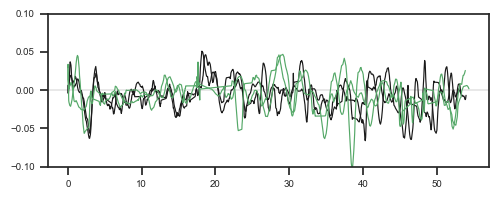

In [31]:
## Plot the Unfamiliarity value for place MBONs during Homing Experiments over distance, change style and save as svg
name_fig = os.path.join(out_folder, "fig_shuttling_trajs.svg")

# Convert mm to inches
width_in_inches = 90 / 25.4
height_in_inches = 35 / 25.4
line_width_points = 0.3/ 25.4 * 72
inner_line_width_points = 0.15 / 25.4 * 72
little_width_points = 0.05 / 25.4 * 72


sns.set_theme(style="ticks")
plt.rcParams.update({
    'font.size': 7,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'axes.labelsize': 8,  # Set font size for x and y labels
    'axes.titlesize': 8,  # Set font size for titles
    'font.family': 'sans-serif',  # Ensure the global setting uses the desired font family
    'font.sans-serif': prop.get_name()  # Apply the specific font from the FontProperties object
})

window_length = 12
polyorder = 2
df_rf_out_expl_o1['smoothed_dif'] = savgol_filter(df_rf_out_expl_o1['dif'], window_length, polyorder)
df_rf_out_expl_o2['smoothed_dif'] = savgol_filter(df_rf_out_expl_o2['dif'], window_length, polyorder)
df_rf_out_expl_o2['smoothed_max'] = savgol_filter(df_rf_out_expl_o2['max'], window_length, polyorder)
df_rf_out_expl_o1['smoothed_max'] = savgol_filter(df_rf_out_expl_o1['max'], window_length, polyorder)


fig, ax = plt.subplots(figsize=(5, 2))

ax.axhline(y=0, color='0.1', linestyle='-',linewidth = little_width_points)


# Plot each trajectory separately
for traj_nb, traj_data in df_rf_out_expl_o1.groupby('trajs_nb'):
    # Project each group's data    
    # Plot the trajectory
    ax.plot(traj_data["cumulative_distance"], traj_data["smoothed_dif"], linewidth=line_width_points, color = 'k')
    # ax.plot(traj_data["cumulative_distance"], traj_data["unfa1"], linewidth=line_width_points)

# Plot each trajectory separately
for traj_nb, traj_data in df_rf_out_expl_o2.groupby('trajs_nb'):
    # Project each group's data    
    # Plot the trajectory
    ax.plot(traj_data["cumulative_distance"], traj_data["smoothed_dif"], linewidth=line_width_points, color = 'g')
    # ax.plot(traj_data["cumulative_distance"], traj_data["unfa1"], linewidth=line_width_points)


ax.set_ylim([-0.1,0.1])

# Remove axis for cleaner look
plt.tight_layout()
# Show the plot
plt.show()


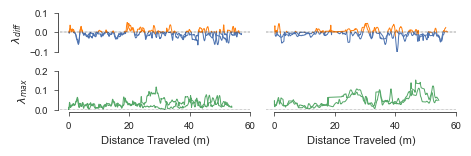

In [32]:
from mpl_toolkits.axes_grid1 import make_axes_locatable

src_out = '../figures/generated_figures'

# Convert mm to inches
width_in_inches = 120 / 25.4
height_in_inches = 40 / 25.4
line_width_points = 0.25 / 25.4 * 72
inner_line_width_points = 0.2 / 25.4 * 72
little_width_points = 0.1 / 25.4 * 72
A_linewidth = 0.3 / 25.4 * 72


# Create the figure with four polar subplots
fig, axes = plt.subplots(2,2, figsize=(width_in_inches, height_in_inches))

# Plot data for the third subplot
# contour3 = axes[0].contourf(theta, dist, zq_dif,levels=level3, cmap=custom_cmap, vmin=-0.6, vmax=0.6)

# for traj_nb, traj_data in df_rf_out_expl_o1.groupby('trajs_nb'):
#     # Project each group's data    
#     # Plot the trajectory
#     axes[0,0].plot(traj_data["cumulative_distance"], traj_data["smoothed_dif"], linewidth=line_width_points, color = 'b')
#     # ax.plot(traj_data["cumulative_distance"], traj_data["unfa1"], linewidth=line_width_points)

# Loop over each group (trajectory)
for traj_nb, traj_data in df_rf_out_expl_o1.groupby('trajs_nb'):
    # Get the x and y values as NumPy arrays
    x = traj_data["cumulative_distance"].values
    y = traj_data["smoothed_dif"].values

    # Initialize the starting index of the current segment
    seg_start = 0

    # Loop over the indices (starting from 1) to detect a sign change
    for i in range(1, len(y)):
        # If the sign changes between y[i-1] and y[i], plot the current segment.
        if np.sign(y[i]) != np.sign(y[i-1]):
            # Define the segment
            x_seg = x[seg_start:i+1]
            y_seg = y[seg_start:i+1]
            # Choose color based on the sign of the first value in the segment.
            color = 'tab:orange' if y_seg[0] >= 0 else 'b'
            axes[0, 0].plot(x_seg, y_seg, linewidth=line_width_points, color=color)
            # Update the start index for the new segment.
            seg_start = i

    # Plot the last segment if any remains.
    if seg_start < len(y):
        x_seg = x[seg_start:]
        y_seg = y[seg_start:]
        color = 'tab:orange' if y_seg[0] >= 0 else 'b'
        axes[0, 0].plot(x_seg, y_seg, linewidth=line_width_points, color=color)


for traj_nb, traj_data in df_rf_out_expl_o1.groupby('trajs_nb'):
    # Project each group's data    
    # Plot the trajectory
    axes[1,0].plot(traj_data["cumulative_distance"], traj_data["smoothed_max"], linewidth=line_width_points, color = 'g')
    # ax.plot(traj_data["cumulative_distance"], traj_data["unfa1"], linewidth=line_width_points)

# for traj_nb, traj_data in df_rf_out_expl_o2.groupby('trajs_nb'):
#     # Project each group's data    
#     # Plot the trajectory
#     axes[0,1].plot(traj_data["cumulative_distance"], traj_data["smoothed_dif"], linewidth=line_width_points, color = 'b')
#     # ax.plot(traj_data["cumulative_distance"], traj_data["unfa1"], linewidth=line_width_points)

for traj_nb, traj_data in df_rf_out_expl_o2.groupby('trajs_nb'):
    # Get the x and y values as NumPy arrays
    x = traj_data["cumulative_distance"].values
    y = traj_data["smoothed_dif"].values

    # Initialize the starting index of the current segment
    seg_start = 0

    # Loop over the indices (starting from 1) to detect a sign change
    for i in range(1, len(y)):
        # If the sign changes between y[i-1] and y[i], plot the current segment.
        if np.sign(y[i]) != np.sign(y[i-1]):
            # Define the segment
            x_seg = x[seg_start:i+1]
            y_seg = y[seg_start:i+1]
            # Choose color based on the sign of the first value in the segment.
            color = 'tab:orange' if y_seg[0] >= 0 else 'b'
            axes[0,1].plot(x_seg, y_seg, linewidth=line_width_points, color=color)
            # Update the start index for the new segment.
            seg_start = i

    # Plot the last segment if any remains.
    if seg_start < len(y):
        x_seg = x[seg_start:]
        y_seg = y[seg_start:]
        color = 'tab:orange' if y_seg[0] >= 0 else 'b'
        axes[0,1].plot(x_seg, y_seg, linewidth=line_width_points, color=color)


for traj_nb, traj_data in df_rf_out_expl_o2.groupby('trajs_nb'):
    # Project each group's data    
    # Plot the trajectory
    axes[1,1].plot(traj_data["cumulative_distance"], traj_data["smoothed_max"], linewidth=line_width_points, color = 'g')
    # ax.plot(traj_data["cumulative_distance"], traj_data["unfa1"], linewidth=line_width_points)




# Customize plots (e.g., grid lines, tick labels)
for ax in axes.flat:
    # ax.set_theta_offset(np.radians(90))
    for line in ax.yaxis.get_gridlines():
        line.set_linestyle('--')
        line.set_linewidth(inner_line_width_points)
        line.set_color('gray')
    for line in ax.xaxis.get_gridlines():
        line.set_linestyle('--')
        line.set_linewidth(inner_line_width_points)
        line.set_color('gray')

# axes[0,0].set_xlim([-180,180])
# axes[0,1].set_xlim([-180,180])

axes[0,0].set_ylim([-0.1,0.1])
axes[0,1].set_ylim([-0.1,0.1])

axes[1,0].set_ylim([0,0.2])
axes[1,1].set_ylim([0,0.2])

axes[0,0].spines["top"].set_linewidth(0)
axes[0,0].spines["bottom"].set_linewidth(0)
axes[0,0].spines["right"].set_linewidth(0)

axes[0,1].spines["top"].set_linewidth(0)
axes[0,1].spines["bottom"].set_linewidth(0)
axes[0,1].spines["right"].set_linewidth(0)
axes[0,1].spines["left"].set_linewidth(0)

axes[1,1].spines["left"].set_linewidth(0)

# axes[1,1].set_xticklabels([0,20,40,60])
# axes[0].set_yticklabels([])
axes[0,0].set_xticks([])
axes[0,0].set_ylabel(r"$\lambda_{diff}$")
axes[1,0].set_ylabel(r"$\lambda_{max}$")
axes[1,0].set_xlabel("Distance Traveled (m)")
axes[1,1].set_xlabel("Distance Traveled (m)")

axes[0,1].set_xticks([])
axes[0,1].set_yticks([])

axes[1,1].set_yticks([])

axes[0,0].axhline(y=0, color='0.1', linestyle='-.',linewidth = little_width_points)
axes[0,1].axhline(y=0, color='0.1', linestyle='-.',linewidth = little_width_points)
axes[1,1].axhline(y=0, color='0.1', linestyle='-.',linewidth = little_width_points)
axes[1,0].axhline(y=0, color='0.1', linestyle='-.',linewidth = little_width_points)


axes[0,0].spines['left'].set_linewidth(inner_line_width_points)
axes[1,0].spines['left'].set_linewidth(inner_line_width_points)
axes[1,0].spines['bottom'].set_linewidth(inner_line_width_points)
axes[1,1].spines['bottom'].set_linewidth(inner_line_width_points)

axes[1,0].set_xticks([0,20,40,60])
axes[1,0].set_xticklabels([0,20,40,60])

axes[1,1].set_xticks([0,20,40,60])
axes[1,1].set_xticklabels([0,20,40,60])

axes[1,1].tick_params(axis='both',length=3, width=0.5)
axes[1,0].tick_params(axis='both',length=3, width=0.5)
axes[0,0].tick_params(axis='both',length=3, width=0.5)

sns.despine(fig,offset=2,trim=True)

plt.tight_layout()
plt.show()

fig.savefig(src_out+'outdor_route_following_dif_max_fam.svg', format='svg')


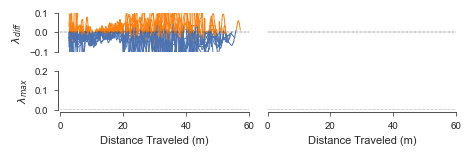

In [33]:
from mpl_toolkits.axes_grid1 import make_axes_locatable


window_length = 12
polyorder = 2
df_lv2_exploit['smoothed_dif'] = savgol_filter(df_lv2_exploit['dif'], window_length, polyorder)

src_out = '../figures/generated_figures'

# Convert mm to inches
width_in_inches = 120 / 25.4
height_in_inches = 40 / 25.4
line_width_points = 0.25 / 25.4 * 72
inner_line_width_points = 0.2 / 25.4 * 72
little_width_points = 0.1 / 25.4 * 72
A_linewidth = 0.3 / 25.4 * 72


# Create the figure with four polar subplots
fig, axes = plt.subplots(2,2, figsize=(width_in_inches, height_in_inches))

# Plot data for the third subplot
# contour3 = axes[0].contourf(theta, dist, zq_dif,levels=level3, cmap=custom_cmap, vmin=-0.6, vmax=0.6)

# for traj_nb, traj_data in df_rf_out_expl_o1.groupby('trajs_nb'):
#     # Project each group's data    
#     # Plot the trajectory
#     axes[0,0].plot(traj_data["cumulative_distance"], traj_data["smoothed_dif"], linewidth=line_width_points, color = 'b')
#     # ax.plot(traj_data["cumulative_distance"], traj_data["unfa1"], linewidth=line_width_points)

# Loop over each group (trajectory)
for traj_nb, traj_data in df_lv2_exploit.groupby('trajs_nb'):
    # Get the x and y values as NumPy arrays
    x = traj_data["cumulative_distance"].values
    y = traj_data["smoothed_dif"].values

    # Initialize the starting index of the current segment
    seg_start = 0

    # Loop over the indices (starting from 1) to detect a sign change
    for i in range(1, len(y)):
        # If the sign changes between y[i-1] and y[i], plot the current segment.
        if np.sign(y[i]) != np.sign(y[i-1]):
            # Define the segment
            x_seg = x[seg_start:i+1]
            y_seg = y[seg_start:i+1]
            # Choose color based on the sign of the first value in the segment.
            color = 'tab:orange' if y_seg[0] >= 0 else 'b'
            axes[0, 0].plot(x_seg, y_seg, linewidth=line_width_points, color=color)
            # Update the start index for the new segment.
            seg_start = i

    # Plot the last segment if any remains.
    if seg_start < len(y):
        x_seg = x[seg_start:]
        y_seg = y[seg_start:]
        color = 'tab:orange' if y_seg[0] >= 0 else 'b'
        axes[0, 0].plot(x_seg, y_seg, linewidth=line_width_points, color=color)


# for traj_nb, traj_data in df_rf_out_expl_o1.groupby('trajs_nb'):
#     # Project each group's data    
#     # Plot the trajectory
#     axes[1,0].plot(traj_data["cumulative_distance"], traj_data["smoothed_max"], linewidth=line_width_points, color = 'g')
#     # ax.plot(traj_data["cumulative_distance"], traj_data["unfa1"], linewidth=line_width_points)

# # for traj_nb, traj_data in df_rf_out_expl_o2.groupby('trajs_nb'):
# #     # Project each group's data    
# #     # Plot the trajectory
# #     axes[0,1].plot(traj_data["cumulative_distance"], traj_data["smoothed_dif"], linewidth=line_width_points, color = 'b')
# #     # ax.plot(traj_data["cumulative_distance"], traj_data["unfa1"], linewidth=line_width_points)

# for traj_nb, traj_data in df_rf_out_expl_o2.groupby('trajs_nb'):
#     # Get the x and y values as NumPy arrays
#     x = traj_data["cumulative_distance"].values
#     y = traj_data["smoothed_dif"].values

#     # Initialize the starting index of the current segment
#     seg_start = 0

#     # Loop over the indices (starting from 1) to detect a sign change
#     for i in range(1, len(y)):
#         # If the sign changes between y[i-1] and y[i], plot the current segment.
#         if np.sign(y[i]) != np.sign(y[i-1]):
#             # Define the segment
#             x_seg = x[seg_start:i+1]
#             y_seg = y[seg_start:i+1]
#             # Choose color based on the sign of the first value in the segment.
#             color = 'tab:orange' if y_seg[0] >= 0 else 'b'
#             axes[0,1].plot(x_seg, y_seg, linewidth=line_width_points, color=color)
#             # Update the start index for the new segment.
#             seg_start = i

#     # Plot the last segment if any remains.
#     if seg_start < len(y):
#         x_seg = x[seg_start:]
#         y_seg = y[seg_start:]
#         color = 'tab:orange' if y_seg[0] >= 0 else 'b'
#         axes[0,1].plot(x_seg, y_seg, linewidth=line_width_points, color=color)


# for traj_nb, traj_data in df_rf_out_expl_o2.groupby('trajs_nb'):
#     # Project each group's data    
#     # Plot the trajectory
#     axes[1,1].plot(traj_data["cumulative_distance"], traj_data["smoothed_max"], linewidth=line_width_points, color = 'g')
#     # ax.plot(traj_data["cumulative_distance"], traj_data["unfa1"], linewidth=line_width_points)




# Customize plots (e.g., grid lines, tick labels)
for ax in axes.flat:
    # ax.set_theta_offset(np.radians(90))
    for line in ax.yaxis.get_gridlines():
        line.set_linestyle('--')
        line.set_linewidth(inner_line_width_points)
        line.set_color('gray')
    for line in ax.xaxis.get_gridlines():
        line.set_linestyle('--')
        line.set_linewidth(inner_line_width_points)
        line.set_color('gray')

# axes[0,0].set_xlim([-180,180])
# axes[0,1].set_xlim([-180,180])

axes[0,0].set_ylim([-0.1,0.1])
axes[0,1].set_ylim([-0.1,0.1])

axes[1,0].set_ylim([0,0.2])
axes[1,1].set_ylim([0,0.2])

axes[0,0].spines["top"].set_linewidth(0)
axes[0,0].spines["bottom"].set_linewidth(0)
axes[0,0].spines["right"].set_linewidth(0)

axes[0,1].spines["top"].set_linewidth(0)
axes[0,1].spines["bottom"].set_linewidth(0)
axes[0,1].spines["right"].set_linewidth(0)
axes[0,1].spines["left"].set_linewidth(0)

axes[1,1].spines["left"].set_linewidth(0)

# axes[1,1].set_xticklabels([0,20,40,60])
# axes[0].set_yticklabels([])
axes[0,0].set_xticks([])
axes[0,0].set_ylabel(r"$\lambda_{diff}$")
axes[1,0].set_ylabel(r"$\lambda_{max}$")
axes[1,0].set_xlabel("Distance Traveled (m)")
axes[1,1].set_xlabel("Distance Traveled (m)")

axes[0,1].set_xticks([])
axes[0,1].set_yticks([])

axes[1,1].set_yticks([])

axes[0,0].axhline(y=0, color='0.1', linestyle='-.',linewidth = little_width_points)
axes[0,1].axhline(y=0, color='0.1', linestyle='-.',linewidth = little_width_points)
axes[1,1].axhline(y=0, color='0.1', linestyle='-.',linewidth = little_width_points)
axes[1,0].axhline(y=0, color='0.1', linestyle='-.',linewidth = little_width_points)


axes[0,0].spines['left'].set_linewidth(inner_line_width_points)
axes[1,0].spines['left'].set_linewidth(inner_line_width_points)
axes[1,0].spines['bottom'].set_linewidth(inner_line_width_points)
axes[1,1].spines['bottom'].set_linewidth(inner_line_width_points)

axes[1,0].set_xticks([0,20,40,60])
axes[1,0].set_xticklabels([0,20,40,60])

axes[1,1].set_xticks([0,20,40,60])
axes[1,1].set_xticklabels([0,20,40,60])

axes[1,1].tick_params(axis='both',length=3, width=0.5)
axes[1,0].tick_params(axis='both',length=3, width=0.5)
axes[0,0].tick_params(axis='both',length=3, width=0.5)

sns.despine(fig,offset=2,trim=True)

plt.tight_layout()
plt.show()

fig.savefig(src_out+'outdor_v2_route_following_dif_max_fam.svg', format='svg')


In [34]:
## Compute the mean distance from the place of interest when the car motivation stop vel command for homing
# Extract the last row of each trajectory
last_rows_df_home = df_home_out_expl_h1.groupby('trajs_nb').tail(1)
mean_home=  last_rows_df_home["d_place"].mean()
print(f"Homing : The mean distance where the motivation switched is : {mean_home} m")


Homing : The mean distance where the motivation switched is : 1.4085182472181392 m


## Indoor shuttling experiments

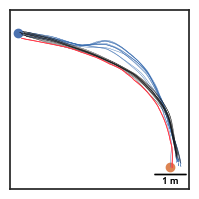

In [35]:
## Plot the indoor shuttling trajectories and save them as svg
name_fig = os.path.join(out_folder, "figure_combined_SHUTTLEsimple.svg")

# Convert mm to inches
width_in_inches = 90 / 25.4
height_in_inches = 130 / 25.4
line_width_points = 0.1 / 25.4 * 72
inner_line_width_points = 0.20 / 25.4 * 72

color_indices = [4]
color_indices_tab2 = [7]
# Create custom color palette from tab20c based on indices
tab20b_custom = [sns.color_palette("Accent", 20)[i] for i in color_indices]
tab20c_custom = [sns.color_palette("Accent", 20)[i] for i in color_indices_tab2]

fig = plt.figure(figsize=(width_in_inches, height_in_inches))

gs = GridSpec(2, 1, figure=fig)
# identical to ax1 = plt.subplot(gs.new_subplotspec((0, 0), colspan=3))

ax1 = fig.add_subplot(gs[0])

# Plot the second plot
# df_rf_convexe_expl_1tra = df_rf_pedest_expl[df_rf_pedest_expl["trajs_nb"]==1]
# ax1.plot(df_rf_convexe_expl_1tra['x'], df_rf_convexe_expl_1tra['y'], linewidth=line_width_points, color='k')

for traj_nb, traj_data in df_rf_shuttling_expl_f2.groupby('inn_trajs_nb'):
    ax1.plot(traj_data['x'], traj_data['y'], linewidth=line_width_points, color=tab20b_custom[0])
ax1.plot(df_rf_shuttling_learn["x"], df_rf_shuttling_learn["y"], c='#ff3847ff',linewidth=inner_line_width_points,zorder=10)
ax1.set_aspect('equal')
ax1.set_box_aspect(1)
ax1.set_xticks([])
ax1.set_yticks([])
add_scale_bar(ax1, 1, '1 m')

for traj_nb, traj_data in df_rf_shuttling_expl_f1.groupby('inn_trajs_nb'):
    ax1.plot(traj_data['x'], traj_data['y'], linewidth=line_width_points, color='k')
ax1.plot(df_rf_shuttling_learn["x"], df_rf_shuttling_learn["y"], c='#ff3847ff',linewidth=inner_line_width_points,zorder=10)
ax1.set_aspect('equal')
ax1.set_box_aspect(1)
ax1.set_xticks([])
ax1.set_yticks([])
add_scale_bar(ax1, 1, '1 m')

ax1.scatter(mean_x_inbound,mean_y_inbound)
ax1.scatter(mean_x_outbound,mean_y_outbound)




fig.savefig(name_fig, format='svg')


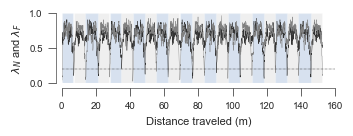

In [36]:
## Plot the Unfamiliarity value for place MBONs during Shuttling Experiments over distance, change style and save as svg
name_fig = os.path.join(out_folder, "figure_combined_motivation2.svg")

# Convert mm to inches
width_in_inches = 90 / 25.4
height_in_inches = 35 / 25.4
line_width_points = 0.1 / 25.4 * 72
inner_line_width_points = 0.15 / 25.4 * 72
little_width_points = 0.05 / 25.4 * 72



sns.set_theme(style="ticks")
plt.rcParams.update({
    'font.size': 7,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'axes.labelsize': 8,  # Set font size for x and y labels
    'axes.titlesize': 8,  # Set font size for titles
    'font.family': 'sans-serif',  # Ensure the global setting uses the desired font family
    'font.sans-serif': prop.get_name()  # Apply the specific font from the FontProperties object
})


df_shuttling_expl_all = df_shuttling_expl_all.sort_values(by='cumulative_distance')


fig, ax2 = plt.subplots(figsize=(width_in_inches, height_in_inches))

# Plot for ax3
sns.lineplot(ax=ax2, data=df_shuttling_expl_all, x="cumulative_distance", y="unfa2", color='0.2', legend=False, linewidth=line_width_points)
sns.lineplot(ax=ax2, data=df_shuttling_expl_all, x="cumulative_distance", y="unfa3", color='0.5', legend=False, linewidth=line_width_points)
ax2.set_ylim([0, 1])
ax2.set_xlim([0, 160])
sns.despine(ax=ax2, offset=4, trim=True)
# Set the external line width for the joint plot
ax2.spines['bottom'].set_linewidth(inner_line_width_points)
ax2.spines['left'].set_linewidth(inner_line_width_points)
ax2.set_yticks([0,0.5,1])
ax2.tick_params(axis='both', width=0.5)  # Adjust tick thickness
ax2.set_xlabel("Distance traveled (m)")
ax2.set_ylabel(r"$\lambda_{N}$ and $\lambda_{F}$")
ax2.axhline(y=0.2, color='0.1', linestyle='-.',linewidth = line_width_points)
ax2.fill_between(df_shuttling_expl_all["cumulative_distance"], 1, where=df_shuttling_expl_all["exp_nb"] == 'f1', facecolor='0.7', alpha=.2)
ax2.fill_between(df_shuttling_expl_all["cumulative_distance"], 1, where=df_shuttling_expl_all["exp_nb"] == 'f2', facecolor=tab20b_custom[0], alpha=.2)

plt.tight_layout()

fig.savefig(name_fig, format='svg')


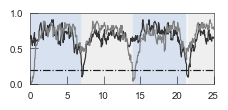

In [37]:
## Plot the zoom of the Shuttling place unfamilairity, save as svg

name_fig = os.path.join(out_folder, "figure_combined_motivation_zoom.svg")

# Convert mm to inches
width_in_inches = 60 / 25.4
height_in_inches = 30 / 25.4
line_width_points = 0.3 / 25.4 * 72
inner_line_width_points = 0.15 / 25.4 * 72
little_width_points = 0.05 / 25.4 * 72

N = 21
fig, ax2 = plt.subplots(figsize=(width_in_inches, height_in_inches))

# Plot for ax3
sns.lineplot(ax=ax2, data=df_shuttling_expl_all, x="cumulative_distance", y="unfa2", color='0.2', legend=False, linewidth=line_width_points)
sns.lineplot(ax=ax2, data=df_shuttling_expl_all, x="cumulative_distance", y="unfa3", color='0.5', legend=False, linewidth=line_width_points)
ax2.set_ylim([0, 1])
ax2.set_xlim([0, 25])
# sns.despine(ax=ax2, offset=4, trim=True)
# Set the external line width for the joint plot
ax2.spines['bottom'].set_linewidth(inner_line_width_points)
ax2.spines['left'].set_linewidth(inner_line_width_points)
ax2.spines['top'].set_linewidth(inner_line_width_points)
ax2.spines['right'].set_linewidth(inner_line_width_points)
ax2.set_yticks([0,0.5,1])
ax2.tick_params(axis='both', width=0.5)  # Adjust tick thickness
ax2.set_xlabel("")
ax2.set_ylabel("")
ax2.axhline(y=0.2, color='0.1', linestyle='-.',linewidth = line_width_points)
# ax2.fill_between(df_shuttling_expl_all["cumulative_distance"], 1, where=df_shuttling_expl_all["exp_nb"] == 'f1', facecolor=tab20c_custom2[0], alpha=.2)
# ax2.fill_between(df_shuttling_expl_all["cumulative_distance"], 1, where=df_shuttling_expl_all["exp_nb"] == 'f2', facecolor=tab20c_custom2[1], alpha=.2)
ax2.fill_between(df_shuttling_expl_all["cumulative_distance"], 1, where=df_shuttling_expl_all["exp_nb"] == 'f1', facecolor='0.7', alpha=.2)
ax2.fill_between(df_shuttling_expl_all["cumulative_distance"], 1, where=df_shuttling_expl_all["exp_nb"] == 'f2', facecolor=tab20b_custom[0], alpha=.2)
plt.tight_layout()

# Adjust tick parameters for aesthetics
ax2.tick_params(axis='both', which='both', direction='in', length=6, width=0.5)
ax2.tick_params(axis='x', which='major', pad=5)  # Adjust spacing to labels if needed
ax2.tick_params(axis='y', which='major', pad=5)  # Adjust spacing to labels if needed

fig.savefig(name_fig, format='svg')


In [38]:
## Counts number of differents trajectories for shuttling
positive_count, negative_count = count_positive_negative_trajectories(df_shuttling_expl_all, 'u2a', 'trajs_nb')
print(f"Number of positive trajectories: {positive_count}")
print(f"Number of negative trajectories: {negative_count}")

Number of positive trajectories: 1
Number of negative trajectories: 1


In [39]:
## Compute the mean distance from the place of interest when the car motivation change vel command for shuttling
last_rows_df = df_shuttling_expl_all.groupby('trajs_nb').tail(1)
mean_sh = last_rows_df["d_place"].mean()
print(f"Shuttling : The mean distance where the motivation switched is : {mean_sh} m")

Shuttling : The mean distance where the motivation switched is : 0.31397721093704073 m


## Overall performance plots for route following and stats

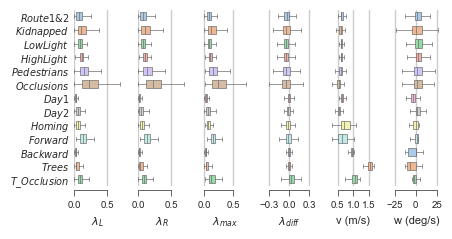

In [67]:
## BoxPlot only the familiarities and the speed in the same color and save as svg

name_fig = os.path.join(out_folder, "familiarities_states_exp_detailled.svg")
width_in_inches = 115 / 25.4
height_in_inches = 60 / 25.4

palette = sns.color_palette("pastel", n_colors=len(df_group_for_mean['exp_nb'].unique()))


sns.set_theme(style="ticks")
# Update Matplotlib rcParams to use the specified font and size globally
plt.rcParams.update({
    'font.size': 7,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'axes.labelsize': 8,  # Set font size for x and y labels
    'axes.titlesize': 8,  # Set font size for titles
    'font.family': 'sans-serif',  # Ensure the global setting uses the desired font family
    'font.sans-serif': prop.get_name()  # Apply the specific font from the FontProperties object
})

fig, ax1 = plt.subplots(ncols=6,figsize=(width_in_inches, height_in_inches),sharey=True)

# Set the external line width to 0.1 for all axes
for ax in ax1:
    ax.spines['top'].set_linewidth(inner_line_width_points)
    ax.spines['bottom'].set_linewidth(inner_line_width_points)
    ax.spines['left'].set_linewidth(inner_line_width_points)
    ax.spines['right'].set_linewidth(inner_line_width_points)

sns.boxplot(ax= ax1[0], data=df_group_for_mean, x="unfa1", y="exp_nb",palette=palette,linewidth=0.5, width=.6,showfliers=False,color='#d5b5ffff')

sns.boxplot(ax= ax1[1], data=df_group_for_mean, x="unfa1", y="exp_nb",palette=palette,linewidth=0.5, width=.6,showfliers=False,color='#d5b5ffff')

sns.boxplot(ax= ax1[2], data=df_group_for_mean, x=df_group_for_mean["max"], y="exp_nb",palette=palette,linewidth=0.5, width=.6,showfliers=False,color='#d5b5ffff')

sns.boxplot(ax= ax1[3], data=df_group_for_mean, x="dif", y="exp_nb",palette=palette,linewidth=0.5, width=.6,showfliers=False,color='#d5b5ffff')

sns.boxplot(ax= ax1[4], data=df_group_for_mean, x="gSpeed", y="exp_nb",palette=palette,linewidth=0.5,width=.6,showfliers=False,color='#d5b5ffff')

sns.boxplot(ax= ax1[5], data=df_group_for_mean, x="vel_ang", y="exp_nb",palette=palette,linewidth=0.5,width=.6,showfliers=False,color='#d5b5ffff')

ax1[0].set_xlim(0,0.7)
ax1[0].set_xticks([0,0.5])
ax1[1].set_xticks([0,0.5])
ax1[1].set_xlim(0,0.7)
# ax1[2].set_xticks([0,0.5])
# ax1[2].set_xlim(0,0.7)
ax1[3].set_xlim(-0.35,0.35)
ax1[3].set_xticks([-0.3,0,0.3])

# ax1[3].set_xlim(-0.3,0.3)

# Tweak the visual presentation
ax1[0].xaxis.grid(True)
ax1[1].xaxis.grid(True)
ax1[2].xaxis.grid(True)
ax1[3].xaxis.grid(True)
ax1[4].xaxis.grid(True)
ax1[5].xaxis.grid(True)

ax1[0].set_ylabel("")
ax1[1].set_ylabel("")
ax1[2].set_ylabel("")
ax1[3].set_ylabel("")
ax1[4].set_ylabel("")
ax1[5].set_ylabel("")

# ax1[0].set_ylabel("Experiments")
ax1[0].set_xlabel(r"$\lambda_{L}$")
ax1[1].set_xlabel(r"$\lambda_{R}$")
ax1[2].set_xlabel(r"$\lambda_{max}$")
ax1[3].set_xlabel(r"$\lambda_{diff}$")
ax1[4].set_xlabel("v (m/s)")
ax1[5].set_xlabel("w (deg/s)")

for ax in ax1:
    ax.tick_params(axis='y', which='both', length=0)  # Hide y-axis ticks but keep the labels
    ax.tick_params(axis='x', which='major', width=inner_line_width_points, length=4)  # Adjust tick width and length
    # Set the external line width for the joint plot
    ax.spines['bottom'].set_linewidth(inner_line_width_points)

xtick_labels = ["$Route 1&2$", "$Kidnapped$", "$Low Light$", "$High Light$", "$Pedestrians$", "$Occlusions$", "$Day1$", "$Day2$", "$Homing$", "$Forward$", "$Backward$","$Trees$","$T\_Occlusion$"]


ax1[1].set_yticklabels(xtick_labels)



plt.tight_layout()
ax.set(ylabel="")
sns.despine(trim=True, left=True,offset=3)

fig.savefig(name_fig, format='svg')



In [41]:
df_group_for_mean['HE_abs'] = ((df_group_for_mean['HE'].abs()))
df_group_for_mean['XTE_abs'] = ((df_group_for_mean['XTE'].abs()))


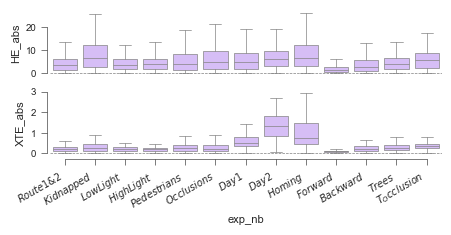

In [42]:
## Plot the lateral and angular error boxplot 

# Assuming necessary variables (out_folder, inner_line_width_points, prop, df_group_for_mean) are defined earlier
name_fig = os.path.join(out_folder, "familiarities_perfromance_detailled.svg")
width_in_inches = 115 / 25.4
height_in_inches = 60 / 25.4

sns.set_theme(style="ticks")

# Update Matplotlib rcParams to use the specified font and size globally
plt.rcParams.update({
    'font.size': 7,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'axes.labelsize': 8,
    'axes.titlesize': 8,
    'font.family': 'sans-serif',
    'font.sans-serif': prop.get_name()
})

fig, ax1 = plt.subplots(nrows=2, figsize=(width_in_inches, height_in_inches), sharex=True)

# Set the external line width to 0.1 for all axes
for ax in ax1:
    ax.spines['top'].set_linewidth(inner_line_width_points)
    ax.spines['bottom'].set_linewidth(inner_line_width_points)
    ax.spines['left'].set_linewidth(inner_line_width_points)
    ax.spines['right'].set_linewidth(inner_line_width_points)

for ax in ax1:
    ax.axhline(0, color='gray', linewidth=0.5, linestyle='--', zorder=0)
    ax.tick_params(axis='y', which='major', width=inner_line_width_points, length=4)
    ax.tick_params(axis='x', which='major', width=inner_line_width_points, length=4)
    ax.spines['bottom'].set_linewidth(inner_line_width_points)

# Plotting on the subplots
sns.boxplot(ax=ax1[0], data=df_group_for_mean, x="exp_nb", y="HE_abs", linewidth=0.5, showfliers=False, color='#d5b5ffff', zorder=20)
sns.boxplot(ax=ax1[1], data=df_group_for_mean, x="exp_nb", y="XTE_abs", linewidth=0.5, showfliers=False, color='#d5b5ffff', zorder=20)

sns.despine(trim=True, offset=2)

# Remove x-axis label and hide x-axis spine and ticks for the first subplot
ax1[0].set_xlabel('')
ax1[0].spines['bottom'].set_visible(False)
ax1[0].tick_params(axis='x', which='both', length=0)

# Set x-axis labels for the first subplot
xtick_labels = ["$Route 1&2$", "$Kidnapped$", "$Low Light$", "$High Light$", "$Pedestrians$", "$Occlusions$", "$Day1$", "$Day2$", "$Homing$", "$Forward$", "$Backward$","$Trees$","$T_Occlusion$"]

# Apply the labels to the first subplot
ax1[1].set_xticklabels(xtick_labels)

# Apply the same labels and rotation to the second subplot if needed
plt.setp(ax1[1].get_xticklabels(), rotation=30, ha='right')

# Adjust layout and save the figure
plt.tight_layout()
plt.savefig(name_fig)
plt.show()


In [43]:
df_test = df_group_for_mean[df_group_for_mean["exp_nb"] =="d2"]

In [44]:
df_group_for_mean

,timestamp,x,y,heading,gSpeed,vel_ang,unfa0,unfa1,unfa2,unfa3,...,latitude,longitude,speedAcc,headingAcc,s,d_place,weights,Group,HE_abs,XTE_abs
11001,8.031675,2.295582,7.504530e-01,-32.317444,0.714961,-5.043468,0.030000,0.010000,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.000031,Out,3.146181,0.030720
11791,10.950926,3.144669,-8.031943e-01,-43.467813,0.635518,-2.736424,0.020000,0.030000,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.000031,Out,0.533505,0.169910
11790,10.831865,3.123978,-7.260174e-01,-42.897613,0.703756,-4.360873,0.020000,0.020000,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.000031,Out,1.103705,0.153619
11789,10.719416,3.104290,-6.546862e-01,-42.375214,0.756813,-5.796537,0.040000,0.010000,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.000031,Out,1.153857,0.154085
11788,10.625333,3.086070,-5.952573e-01,-41.787290,0.778654,-6.569051,0.050000,0.010000,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.000031,Out,1.741781,0.138435
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28292,23.493480,698442.120096,4.789355e+06,-158.108095,0.850853,2.022882,0.100000,0.033333,NaN,NaN,...,43.230893,5.443747,107.458839,6.634671,NaN,NaN,0.000037,Out,9.009679,0.460556
28291,23.435725,698442.133329,4.789355e+06,-159.096316,0.848972,2.029052,0.140000,0.060000,NaN,NaN,...,43.230893,5.443747,108.211062,6.644023,NaN,NaN,0.000037,Out,8.021458,0.486304
28290,23.351962,698442.152522,4.789355e+06,-160.529558,0.846245,2.038000,0.173333,0.053333,NaN,NaN,...,43.230894,5.443747,109.302030,6.657586,NaN,NaN,0.000037,Out,4.571778,0.525960
28304,24.426930,698441.936733,4.789355e+06,-146.514507,0.862184,1.906614,0.093333,0.253333,NaN,NaN,...,43.230888,5.443744,100.189790,6.425534,NaN,NaN,0.000037,Out,20.603266,0.535474


Number of data points used: 28199


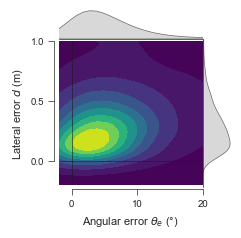

In [45]:
# ## Plots the 2d histogram of the lateral and angular error for all the experiments weighted (normalized) and save as svg

name_fig = os.path.join(out_folder, "overall_performance.svg")
# Set figure size
width_in_inches = 60 / 25.4
height_in_inches = 60 / 25.4

# Create the JointGrid plot with specified height
g = sns.JointGrid(data=df_group_for_mean, x="HE_abs", y="XTE_abs", height=height_in_inches, space=0)

g.plot_joint(
    sns.kdeplot, 
    fill=True, 
    cmap='viridis',
    thresh=0,
)

# Replace marginals with KDE for a smoother, more integrated appearance
g.plot_marginals(
    sns.kdeplot, 
    fill=True, 
    color='0.4',
    linewidth=0.5,
)

# Set plot aspects and limits
g.ax_joint.set_box_aspect(1)
g.ax_joint.set_xlim(-2, 20)
g.ax_joint.set_xticks([0, 10, 20])
g.ax_joint.set_ylim(-0.2, 1)
g.ax_joint.set_yticks([0, 0.5, 1])

# Set the line widths for the plots
inner_line_width_points = 0.5  # Define this as needed for your style
for ax in [g.ax_joint, g.ax_marg_x, g.ax_marg_y]:
    for spine in ax.spines.values():
        spine.set_linewidth(inner_line_width_points)

# Hide the right and top ticks in the marginal plots
g.ax_marg_x.tick_params(axis='x', which='both', length=0)
g.ax_marg_x.tick_params(axis='y', which='both', length=0)
g.ax_marg_y.tick_params(axis='x', which='both', length=0)
g.ax_marg_y.tick_params(axis='y', which='both', length=0)

# Set custom labels for x and y axes
g.ax_joint.set_xlabel(r"Angular error $\theta_e$ (°)")
g.ax_joint.set_ylabel(r"Lateral error $d$ (m)")

# Customize KDE line width in marginal plots
for line in g.ax_marg_x.get_lines():
    line.set_linewidth(0.5)
for line in g.ax_marg_y.get_lines():
    line.set_linewidth(0.5)

# Add grid lines and highlight x=0 and y=0 lines
g.ax_joint.grid(True, alpha=0.3)
g.ax_joint.axhline(y=0, color='k', linewidth=0.4)
g.ax_joint.axvline(x=0, color='k', linewidth=0.4)

# Despine the joint plot
sns.despine(ax=g.ax_joint, trim=True, offset=3)
g.ax_joint.tick_params(axis='both', which='major', width=inner_line_width_points, length=4)

# Save the figure
g.savefig(name_fig, format='svg')

n = len(df_group_for_mean)
print(f"Number of data points used: {n}")

Number of data points used: 28199


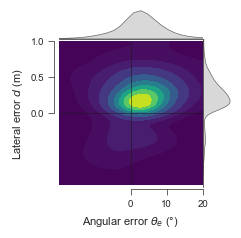

In [46]:
## Plots the 2d histogram of the lateral and angular error for all the experiments weighted (normalized) and save as svg

name_fig = os.path.join(out_folder, "overall_performance_noabs.svg")
# Set figure size
width_in_inches = 60 / 25.4
height_in_inches = 60 / 25.4

# Create the JointGrid plot with specified height
g = sns.JointGrid(data=df_group_for_mean, x="HE", y="XTE", height=height_in_inches, space=0)

g.plot_joint(
    sns.kdeplot, 
    fill=True, 
    cmap='viridis',
    thresh=0,
)

# Replace marginals with KDE for a smoother, more integrated appearance
g.plot_marginals(
    sns.kdeplot, 
    fill=True, 
    color='0.4', 
    linewidth=0.5)

# Set plot aspects and limits
g.ax_joint.set_box_aspect(1)
# g.ax_joint.set_xlim(-2, 20)
# g.ax_joint.set_xticks([0, 10, 20])
# g.ax_joint.set_ylim(-0.2, 1)
# g.ax_joint.set_yticks([0, 0.5, 1])

g.ax_joint.set_xlim(-20, 20)
g.ax_joint.set_xticks([0, 10, 20])
g.ax_joint.set_ylim(-1, 1)
g.ax_joint.set_yticks([0, 0.5, 1])


# Set the line widths for the plots
inner_line_width_points = 0.5  # Define this as needed for your style
for ax in [g.ax_joint, g.ax_marg_x, g.ax_marg_y]:
    for spine in ax.spines.values():
        spine.set_linewidth(inner_line_width_points)

# Hide the right and top ticks in the marginal plots
g.ax_marg_x.tick_params(axis='x', which='both', length=0)
g.ax_marg_x.tick_params(axis='y', which='both', length=0)
g.ax_marg_y.tick_params(axis='x', which='both', length=0)
g.ax_marg_y.tick_params(axis='y', which='both', length=0)

# Set custom labels for x and y axes
g.ax_joint.set_xlabel(r"Angular error $\theta_e$ (°)")
g.ax_joint.set_ylabel(r"Lateral error $d$ (m)")

# Customize KDE line width in marginal plots
for line in g.ax_marg_x.get_lines():
    line.set_linewidth(0.5)
for line in g.ax_marg_y.get_lines():
    line.set_linewidth(0.5)

# Add grid lines and highlight x=0 and y=0 lines
g.ax_joint.grid(True, alpha=0.3)
g.ax_joint.axhline(y=0, color='k', linewidth=0.4)
g.ax_joint.axvline(x=0, color='k', linewidth=0.4)

# Despine the joint plot
sns.despine(ax=g.ax_joint, trim=True, offset=3)
g.ax_joint.tick_params(axis='both', which='major', width=inner_line_width_points, length=4)

# Save the figure
g.savefig(name_fig, format='svg')

n = len(df_group_for_mean)
print(f"Number of data points used: {n}")


In [47]:
## Print the maximum lenght ffor one trajs in each xps
unique_total_lengths = df_group_for_mean.groupby('exp_nb')['total_length'].first()
print(unique_total_lengths)

exp_nb
A1                  8.210929
A2                  8.092209
b3                  7.869337
b4                  7.757686
c2                  8.946144
c3                  8.156343
d1                 53.233577
d2                 54.341595
e1                 51.449009
f1                159.579428
f2                159.579428
out_L_v2                 NaN
out_L_v2_noise           NaN
Name: total_length, dtype: float64


In [48]:
## calculat the distance travaled in total and the number of differents trajectories

df_end_distances = df_grouped.loc[df_grouped.groupby(['exp_nb', 'trajs_nb'])['timestamp'].idxmax()]
df_end_distances = df_end_distances.reset_index(drop=True)

nb = df_end_distances["cumulative_distance"].count() + 22
## Add + 22 because it count the shuttling as one route but we count route as between two point
print(f'The number of autonomous route between two point is {nb}')

dist = df_end_distances["cumulative_distance"].sum()
print(f'The summed autonomously traveled distance is {dist} m')

The number of autonomous route between two point is 113
The summed autonomously traveled distance is 1576.6034168979381 m


In [49]:
# Function to calculate weighted median
def weighted_median(data, weights):
    sorted_data, sorted_weights = zip(*sorted(zip(data, weights)))
    cumulative_weight = np.cumsum(sorted_weights)
    cutoff = sum(sorted_weights) / 2.0
    return sorted_data[np.where(cumulative_weight >= cutoff)[0][0]]

# Calculate median and MAD for each experiment
grouped = df_group_for_mean.groupby('exp_nb').agg(
    median=('XTE_abs', 'median'),
    count=('XTE_abs', 'count')
).reset_index()

# Calculate the overall weighted median
overall_median = weighted_median(grouped['median'], grouped['count'])

# Calculate MAD for the combined data
mad_values = df_group_for_mean['XTE'] - df_group_for_mean.groupby('exp_nb')['XTE'].transform('median')
overall_mad = np.median(np.abs(mad_values))

print(f"Lateral Overall Median Error: {overall_median}")
print(f"Lateral Overall Median Absolute Deviation: {overall_mad}")

# Calculate median and MAD for each experiment for HE
grouped = df_group_for_mean.groupby('exp_nb').agg(
    median=('HE_abs', 'median'),
    count=('HE_abs', 'count')
).reset_index()

# Calculate the overall weighted median
overall_median = weighted_median(grouped['median'], grouped['count'])

# Calculate MAD for the combined data
mad_values = df_group_for_mean['HE'] - df_group_for_mean.groupby('exp_nb')['HE'].transform('median')
overall_mad = np.median(np.abs(mad_values))

print(f"Angular Overall Median Error: {overall_median}")
print(f"Angular Overall Median Absolute Deviation: {overall_mad}")


Lateral Overall Median Error: 0.240767566938957
Lateral Overall Median Absolute Deviation: 0.137769492233199
Angular Overall Median Error: 4.0006993077964
Angular Overall Median Absolute Deviation: 2.728557492041205


In [50]:
print_median_mad(df_group_for_mean, 'exp_nb', ['XTE_abs', 'HE_abs', 'max', 'dif', 'vel_ang', 'gSpeed'])



XTE_abs Statistics by exp_nb:
                  Median       MAD
exp_nb                            
A1              0.217652  0.096166
A2              0.265667  0.137203
b3              0.240768  0.082732
b4              0.202906  0.063712
c2              0.266415  0.147554
c3              0.225604  0.133087
d1              0.494416  0.193794
d2              1.319408  0.479107
e1              0.774015  0.403063
f1              0.109878  0.035331
f2              0.193637  0.078084
out_L_v2        0.284751  0.121706
out_L_v2_noise  0.381729  0.106135

HE_abs Statistics by exp_nb:
                  Median       MAD
exp_nb                            
A1              3.446040  2.252815
A2              6.459607  4.190303
b3              3.809417  2.087116
b4              3.875639  2.333923
c2              4.049647  2.815286
c3              4.722868  3.289724
d1              4.761972  3.252675
d2              6.186454  3.240929
e1              6.468179  4.253342
f1              1.262102  0.8

## Statistical Analysis

In [51]:
df_group_for_mean["exp_nb"].unique()

array(['A1', 'A2', 'b3', 'b4', 'c2', 'c3', 'd1', 'd2', 'e1', 'f1', 'f2',
       'out_L_v2', 'out_L_v2_noise'], dtype=object)

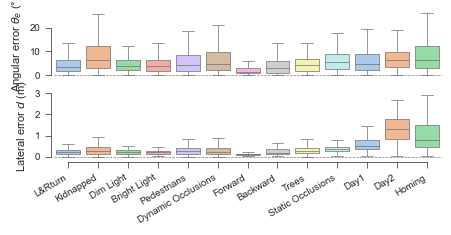

In [52]:
order = ['A1', 'A2', 'b3', 'b4', 'c2', 'c3', 'f1', 'f2','out_L_v2', 'out_L_v2_noise', 'd1', 'd2', 'e1']

df_group_for_mean["exp_nb"] = pd.Categorical(df_group_for_mean["exp_nb"], categories=order, ordered=True)


# Assuming necessary variables (out_folder, inner_line_width_points, prop, df_group_for_mean) are defined earlier
name_fig = os.path.join(out_folder, "familiarities_performance_detailled.svg")
width_in_inches = 115 / 25.4
height_in_inches = 60 / 25.4

sns.set_theme(style="ticks")

# Update Matplotlib rcParams to use the specified font and size globally
plt.rcParams.update({
    'font.size': 7,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'axes.labelsize': 8,
    'axes.titlesize': 8,
    'font.family': 'sans-serif',
    'font.sans-serif': prop.get_name()
})

fig, ax1 = plt.subplots(nrows=2, figsize=(width_in_inches, height_in_inches), sharex=True)

# Set the external line width to 0.1 for all axes
for ax in ax1:
    ax.spines['top'].set_linewidth(inner_line_width_points)
    ax.spines['bottom'].set_linewidth(inner_line_width_points)
    ax.spines['left'].set_linewidth(inner_line_width_points)
    ax.spines['right'].set_linewidth(inner_line_width_points)

for ax in ax1:
    ax.axhline(0, color='gray', linewidth=0.5, linestyle='--', zorder=0)
    ax.tick_params(axis='y', which='major', width=inner_line_width_points, length=4)
    ax.tick_params(axis='x', which='major', width=inner_line_width_points, length=4)
    ax.spines['bottom'].set_linewidth(inner_line_width_points)

# Define pastel colors for the boxplot palette
palette = sns.color_palette("pastel", n_colors=len(df_group_for_mean['exp_nb'].unique()))

# Plotting on the subplots with boxplot
sns.boxplot(ax=ax1[0], data=df_group_for_mean, x="exp_nb", y="HE_abs", linewidth=0.5, 
            showfliers=False, palette=palette, zorder=20)
ax1[0].set_ylabel(r"Angular error $\theta_e$ (°)")

sns.boxplot(ax=ax1[1], data=df_group_for_mean, x="exp_nb", y="XTE_abs", linewidth=0.5, 
            showfliers=False, palette=palette, zorder=20)
ax1[1].set_ylabel("Lateral error $d$ (m)")

sns.despine(trim=True, offset=2)

# Remove x-axis label and hide x-axis spine and ticks for the first subplot
ax1[0].set_xlabel('')
ax1[1].set_xlabel('')

ax1[0].spines['bottom'].set_visible(False)
ax1[0].tick_params(axis='x', which='both', length=0)

# Set x-axis labels for the second subplot
xtick_labels = ["L&Rturn", "Kidnapped", "Dim Light", "Bright Light", "Pedestrians", "Dynamic Occlusions", "Forward", "Backward", 
                 "Trees", 'Static Occlusions', "Day1", "Day2", "Homing"]

ax1[1].set_xticklabels(xtick_labels)
plt.setp(ax1[1].get_xticklabels(), rotation=30, ha='right')

# Adjust layout and save the figure
plt.tight_layout()
plt.savefig(name_fig, format='svg')
plt.show()

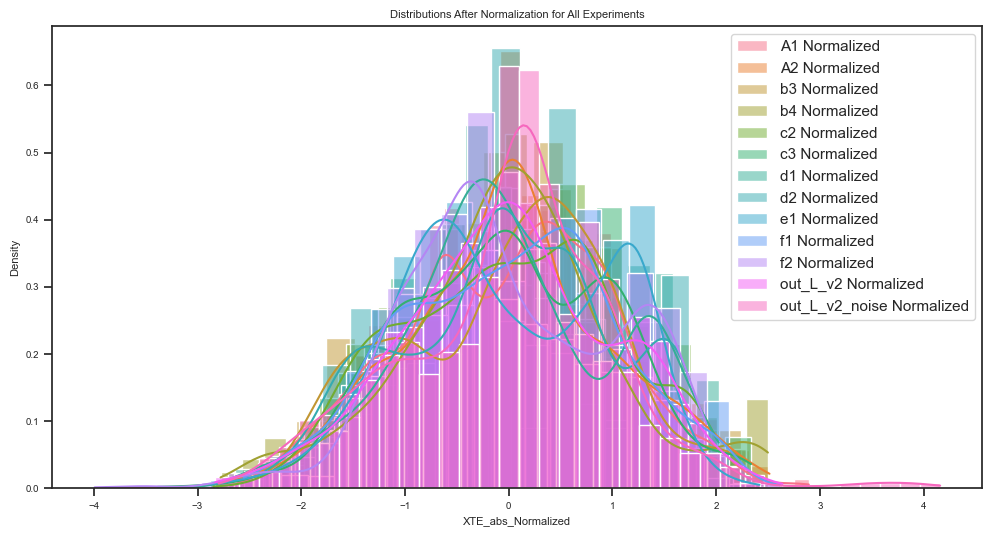

Kruskal-Wallis Test Statistic: 2.101768687607424, p-value: 0.9992331933501655


In [53]:
# Function to apply PowerTransformer transformation and add a new column
def normalize_group(data):
    pt = PowerTransformer(method='box-cox', standardize=True)
    # Apply transformation and add it as a new column 'XTE_abs_Normalized'
    data['XTE_abs_Normalized'] = pt.fit_transform((data['XTE_abs'] + 1e-5).values.reshape(-1, 1)).flatten()
    return data

# Apply normalization to each group in df_group_for_mean based on 'exp_nb'
df_group_for_mean = df_group_for_mean.groupby('exp_nb', group_keys=False).apply(normalize_group)

plt.figure(figsize=(12, 6))

# Get unique experiment numbers
unique_experiments = df_group_for_mean['exp_nb'].unique()

# Define colors for each group
colors = sns.color_palette("husl", len(unique_experiments))

# Plot normalized distributions for each experiment group
for idx, exp in enumerate(unique_experiments):
    group_normalized = df_group_for_mean[df_group_for_mean['exp_nb'] == exp]['XTE_abs_Normalized']
    
    # Plot the normalized data with a different color for each group
    sns.histplot(group_normalized, kde=True, color=colors[idx], label=f'{exp} Normalized', stat="density")

# Add titles and legends
plt.title('Distributions After Normalization for All Experiments')
plt.legend()
plt.show()

# Prepare data for the Kruskal-Wallis test
# Extract normalized data for each experiment into a list
groups = [df_group_for_mean[df_group_for_mean['exp_nb'] == exp]['XTE_abs_Normalized'] for exp in unique_experiments]

# Perform Kruskal-Wallis test across all normalized experiment groups
kruskal_stat, kruskal_p_value = kruskal(*groups)

# Print the Kruskal-Wallis test results
print(f"Kruskal-Wallis Test Statistic: {kruskal_stat}, p-value: {kruskal_p_value}")


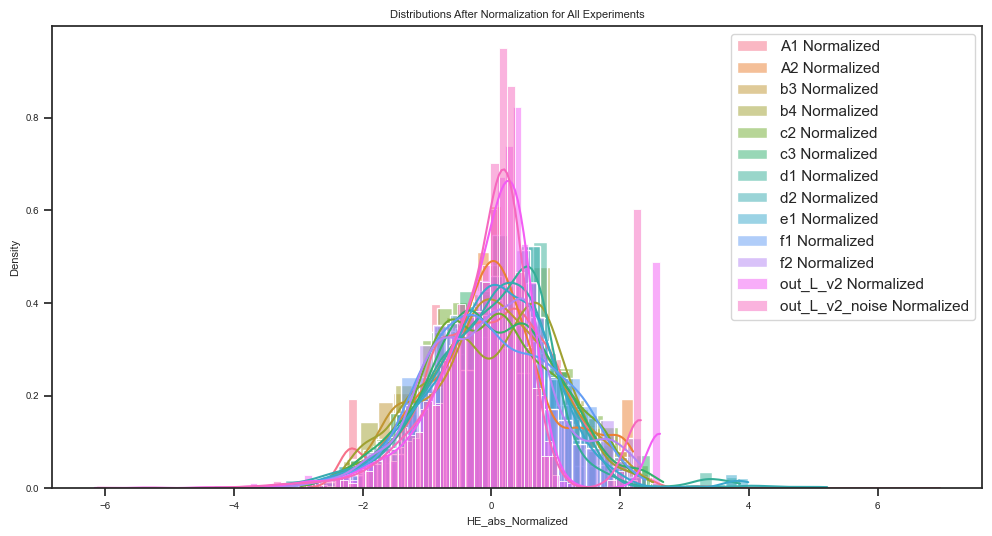

Kruskal-Wallis Test Statistic: 8.21589411891182, p-value: 0.7680395585862374


In [54]:
# Function to apply PowerTransformer transformation and add a new column
def normalize_group(data):
    pt = PowerTransformer(method='box-cox', standardize=True)
    # Apply transformation and add it as a new column 'XTE_abs_Normalized'
    data['HE_abs_Normalized'] = pt.fit_transform((data['HE_abs'] + 1e-5).values.reshape(-1, 1)).flatten()
    return data

# Apply normalization to each group in df_group_for_mean based on 'exp_nb'
df_group_for_mean = df_group_for_mean.groupby('exp_nb', group_keys=False).apply(normalize_group)

plt.figure(figsize=(12, 6))

# Get unique experiment numbers
unique_experiments = df_group_for_mean['exp_nb'].unique()

# Define colors for each group
colors = sns.color_palette("husl", len(unique_experiments))

# Plot normalized distributions for each experiment group
for idx, exp in enumerate(unique_experiments):
    group_normalized = df_group_for_mean[df_group_for_mean['exp_nb'] == exp]['HE_abs_Normalized']
    
    # Plot the normalized data with a different color for each group
    sns.histplot(group_normalized, kde=True, color=colors[idx], label=f'{exp} Normalized', stat="density")

# Add titles and legends
plt.title('Distributions After Normalization for All Experiments')
plt.legend()
plt.show()

# Prepare data for the Kruskal-Wallis test
# Extract normalized data for each experiment into a list
groups = [df_group_for_mean[df_group_for_mean['exp_nb'] == exp]['HE_abs_Normalized'] for exp in unique_experiments]

# Perform Kruskal-Wallis test across all normalized experiment groups
kruskal_stat, kruskal_p_value = kruskal(*groups)

# Print the Kruskal-Wallis test results
print(f"Kruskal-Wallis Test Statistic: {kruskal_stat}, p-value: {kruskal_p_value}")
